### Notebook to show the neuro specific significant results in order to find biologically meaningful findings
- Load the variant region map and the enformer file and combine them
- plots but looks messy: variant explaining with neuro focus in `/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/manuskript_neuro_explain_variants.ipynb`

In [106]:
import pandas as pd
import numpy as np
import yaml

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()



In [184]:
# helpful function to investigate the variant metadata file
def get_enformer_class_list(enformer_variant_info):
    """
    return the enformer class list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    enformer_class_list = []
    for elem in enformer_variant_info:
        enformer_class_list.append(elem[2])
    return list(set(enformer_class_list))

def get_variant_type_list(enformer_variant_info):
    """
    return the variant type list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    variant_type_list = []
    for elem in enformer_variant_info:
        variant_type_list.append(elem[1])
    return list(set(variant_type_list))

def get_gene_set_list(enformer_variant_info):
    """
    return the geme set list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    gene_set_list = []
    for elem in enformer_variant_info:
        gene_set_list.append(elem[0])
    return list(set(gene_set_list))


def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list


def split_group(header):
    colon_split = header.split(':')
    if len(colon_split) > 2:
        return ':'.join(colon_split[1:])
    return colon_split[1]


def extract_from_list(column_list):
    if len(column_list) == 1:
        return column_list[0]
    else:
        print(column_list)
        raise ValueError("Your list cannot be extracted")
        return column_list


def get_AF(info):
    """
    get AF from INFO: 'AF=0.0126802;AC=1930' => 0.0126802
    """
    return float(info.split(';')[0].split('=')[1])


def get_AC(info):
    """
    get AC from INFO: 'AF=0.0126802;AC=1930' => 1930
    """
    return int(info.split(';')[1].split('=')[1])


def get_variant_type(AF, AC):
    """
    get ultra-rare, common, singleton from INFO: 'AF=0.0126802;AC=1930' => common
    """
    if AF > 0.05:
        return 'common'
    elif AF > 0.01:
        return 'rare'
    elif AC == 1:
        return 'singleton'
    else:
        return 'ultra-rare'

In [185]:
# variant region map
variant_table = pd.read_csv(config['files']['final_design']['final_design_variant_region_map'], sep="\t")
variant_table

from ast import literal_eval
common_and_enformer_variants = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t")
common_and_enformer_variants['enformer_variant_info'] = common_and_enformer_variants['enformer_variant_info'].apply(literal_eval) # read as list
# important_columns = ['ID', 'INFO', 'enformer_variant_info']
# common_and_enformer_variants = common_and_enformer_variants[[important_columns]]
# read mpralm results
bc_mpralm_resequencing = pd.read_csv(config['files']['creating']['toptable_bcMPRAlm_resequencing'], sep="\t")
print('Number of resequencing results: ', bc_mpralm_resequencing.shape[0])
# bc_mpralm = pd.read_csv(config['files']['creating']['toptable_bcMPRAlm'], sep="\t")
# print('Number of previous results: ', bc_mpralm.shape[0])

Number of resequencing results:  36694


#### For the downstream analysis the split between common and rare is interesting


In [186]:
# # remove unused columns
# common_and_enformer_variants.head()
# focus on important columns => add the "," variants


In [187]:
bc_mpralm_resequencing.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...


In [188]:
print('number of variants after MPRAlm: ', bc_mpralm_resequencing['variant_id'].nunique())
print('number of tested variants after MPRAlm: ', bc_mpralm_resequencing['variant_id'].str.startswith('cardiac_neuro_cava_random').sum())

number of variants after MPRAlm:  36694
number of tested variants after MPRAlm:  36168


### Cleaning up this messy notebook:
- I want a file/df which has the metadata information of the variants after MPRAlm
  - Sice the matching will not be perfect: what is the proportion of missing variants of variant type and gene set?
- I want to know the exact numbers of singleton, ultra-rare and common variants in this dataset
- I want to know the ratios between the numbers in the design and the significant results
- I want to plot the ratios of significant variants for the groups of common, ultra-rare, singleton (should I increase resolution for rare and common?)

In [189]:
bc_mpralm_resequencing['Variant_without_group'] = bc_mpralm_resequencing['variant_id'].apply(split_group)
bc_mpralm_resequencing['label'] = bc_mpralm_resequencing['variant_id'].apply(hf.get_label)
bc_mpralm_resequencing_metadata = bc_mpralm_resequencing.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID', how='left')
not_merged_bc_mpralm_resequencing_metadata = bc_mpralm_resequencing_metadata.loc[bc_mpralm_resequencing_metadata['enformer_variant_info'].isna()]
matched_bc_mpralm_resequencing_metadata = bc_mpralm_resequencing_metadata.loc[~bc_mpralm_resequencing_metadata['enformer_variant_info'].isna()]
print(f'Number of significant results with metadata annotation: {matched_bc_mpralm_resequencing_metadata.shape[0]}') # are only tested variants (only enformer annotation for them)

Number of significant results with metadata annotation: 35971


#### Check how the numbers of the variant types are 

In [190]:
def investigate_list(element_list):
    print(type(element_list))

def get_effect_direction(variant_log2):
    if variant_log2 > 0:
        return 'pos'
    elif variant_log2 < 0:
        return 'neg'
    return np.nan

In [191]:
neuro_high_effect_output_path = '/home/kisa/coding/80K_MPRA/high_effect_results/neuro_30_high_effect_variants.tsv'

In [192]:
# explode enformer_variant_info

matched_bc_mpralm_resequencing_metadata['enformer_class_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_enformer_class_list)
matched_bc_mpralm_resequencing_metadata['gene_set_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_gene_set_list)
matched_bc_mpralm_resequencing_metadata['variant_type_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_variant_type_list)
matched_bc_mpralm_resequencing_metadata['effect_direction'] = matched_bc_mpralm_resequencing_metadata['logFC'].apply(get_effect_direction)
neuro_matched_bc_mpralm_resequencing_metadata = matched_bc_mpralm_resequencing_metadata.loc[matched_bc_mpralm_resequencing_metadata['gene_set_list'].apply(lambda x: True if 'neuro' in x else False)]
neuro_matched_bc_mpralm_resequencing_metadata['gene_set_list'].value_counts()
neuro_significant_resequencing = neuro_matched_bc_mpralm_resequencing_metadata.loc[neuro_matched_bc_mpralm_resequencing_metadata['adj.P.Val'] < 0.05]

neuro_significant_resequencing['abs_log2FC'] = neuro_significant_resequencing['logFC'].abs()
sorted_neuro_significant_resequencing = neuro_significant_resequencing.sort_values(by='abs_log2FC', ascending=False)
sorted_neuro_significant_resequencing
print(f'Number of significant results neuro specific: ', sorted_neuro_significant_resequencing.shape[0])
sorted_neuro_significant_resequencing[:30]['effect_direction'].value_counts()
# sorted_neuro_significant_resequencing[:30].sort_values(by='logFC', ascending=False).to_csv(neuro_high_effect_output_path, sep="\t", index=False)

Number of significant results neuro specific:  236


/tmp/ipykernel_262665/4257165402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['enformer_class_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_enformer_class_list)
/tmp/ipykernel_262665/4257165402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['gene_set_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_gene_set_list)
/tmp/ipykernel_262665/4257165402

effect_direction
pos    17
neg    13
Name: count, dtype: int64

##### Investigate genomizer enhancer variants

In [193]:
def get_chr_pos_pattern_genomizer(row):
    return f"{row['Chr'].split('chr')[1]}-{row['Position']}-{row['Ref']}-{row['Alt']}"

In [194]:
genomizer_variants_path = '/home/kisa/coding/80K_MPRA/info/genomizer/genomizer_enhancer_mutations.csv'
genomizer_vars = pd.read_csv(genomizer_variants_path, sep=";")
genomizer_vars['chr_pos_ref_alt'] = genomizer_vars.apply(get_chr_pos_pattern_genomizer, axis=1)
genomizer_vars

,Chr,Position,Ref,Alt,OMIM,Gene,PMID,chr_pos_ref_alt
0,chr1,21890663,G,A,MIM 241500,ALPL,10679946,1-21890663-G-A
1,chr1,209989478,C,CA,MIM 119300,IRF6,24442519,1-209989478-C-CA
2,chr2,219524871,A,G,MIM 124000,BCS1L,19389488,2-219524871-A-G
3,chr7,156061506,C,T,MIM 142945,SHH,18836447,7-156061506-C-T
4,chr7,156583831,T,C,MIM 174500,SHH,17152067,7-156583831-T-C
5,chr7,156583949,G,C,MIM 174500,SHH,17152067,7-156583949-G-C
6,chr7,156583951,G,A,MIM 174500,SHH,22903933,7-156583951-G-A
7,chr7,156583968,T,TTAAGGAAGTGATT,MIM 174500,SHH,22495965,7-156583968-T-TTAAGGAAGTGATT
8,chr7,156584107,A,C,MIM 174500,SHH,20068592,7-156584107-A-C
9,chr7,156584153,T,C,MIM 174500,SHH,25382487,7-156584153-T-C


In [195]:
genomizer_vars.merge(matched_bc_mpralm_resequencing_metadata, on="chr_pos_ref_alt", how='left')

,Chr,Position,Ref,Alt,OMIM,Gene,PMID,chr_pos_ref_alt,logFC,AveExpr,...,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,effect_direction
0,chr1,21890663,G,A,MIM 241500,ALPL,10679946,1-21890663-G-A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,209989478,C,CA,MIM 119300,IRF6,24442519,1-209989478-C-CA,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr2,219524871,A,G,MIM 124000,BCS1L,19389488,2-219524871-A-G,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chr7,156061506,C,T,MIM 142945,SHH,18836447,7-156061506-C-T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chr7,156583831,T,C,MIM 174500,SHH,17152067,7-156583831-T-C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,chr7,156583949,G,C,MIM 174500,SHH,17152067,7-156583949-G-C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,chr7,156583951,G,A,MIM 174500,SHH,22903933,7-156583951-G-A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,chr7,156583968,T,TTAAGGAAGTGATT,MIM 174500,SHH,22495965,7-156583968-T-TTAAGGAAGTGATT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,chr7,156584107,A,C,MIM 174500,SHH,20068592,7-156584107-A-C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,chr7,156584153,T,C,MIM 174500,SHH,25382487,7-156584153-T-C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [196]:
# matched_bc_mpralm_resequencing_metadata['variant_type_list'].value_counts()

In [197]:
# matched_bc_mpralm_resequencing_metadata['variant_type_list'].value_counts()

##### Investigate not matchable results
- label
- cardiac_neuro_cava_random    197
- GC_Selvarajan                157
- GC_Mendelian_variants        149
- GC_Kircher                   143
- C_positive_heart_CAD          39
- GC_Atrial_fib                 20
- GC_Mohlke                     13
- GC_Liang                       5
- mostly controls (expected)
- unexpected: 197 tested

In [198]:
not_merged_bc_mpralm_resequencing_metadata['label'].value_counts()

label
cardiac_neuro_cava_random    197
GC_Selvarajan                157
GC_Mendelian_variants        149
GC_Kircher                   143
C_positive_heart_CAD          39
GC_Atrial_fib                 20
GC_Mohlke                     13
GC_Liang                       5
Name: count, dtype: int64

investigate the unexpected variants
- all of these are combined variants (same variant two different gene associations)
- e.g. MYH6|ENSG00000197616.13|EH38E1703157|14-23437064-G-C cardiac associated and MYH7|ENSG00000092054.13|EH38E1703157|14-23437064-G-C cava associated
- rescue these and increase the number of variants you have a information for => overall number cannot increase so change the enformer common variant ids accordingly
    - find the rows in the original data, make tuples out of them

In [199]:
def check_for_colon(header):
    return "," in header

bc_mpralm_resequencing['variant_id'].apply(check_for_colon).sum()
# pigenhole principle: if we cannot match 197 with a ',' and there are 197 with a colon in the data then these are all
colon_combined_df = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['variant_id'].apply(check_for_colon)]
print(colon_combined_df.shape[0])

197


In [200]:
not_merged_bc_mpralm_resequencing_metadata.loc[not_merged_bc_mpralm_resequencing_metadata['label'] == 'cardiac_neuro_cava_random']['variant_id'].to_list()

['cardiac_neuro_cava_random:MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G,MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G',
 'cardiac_neuro_cava_random:MYH6|ENSG00000197616.13|EH38E1703157|14-23437064-G-C,MYH7|ENSG00000092054.13|EH38E1703157|14-23437064-G-C',
 'cardiac_neuro_cava_random:CDKN2A|ENSG00000147889.18|EH38E3877964|9-21966222-G-A,CDKN2B|ENSG00000147883.12|EH38E3877964|9-21966222-G-A',
 'cardiac_neuro_cava_random:EEF1A2|ENSG00000101210.13|EH38E3448853|20-63504242-C-T,KCNQ2|ENSG00000075043.20|EH38E3448853|20-63504242-C-T',
 'cardiac_neuro_cava_random:APOL2|ENSG00000128335.14|EH38E3478603|22-36248105-G-A,APOL4|ENSG00000100336.18|EH38E3478603|22-36248105-G-A',
 'cardiac_neuro_cava_random:CNPY3|ENSG00000137161.18|EH38E3708674|6-42936025-C-G,PPP2R5D|ENSG00000112640.16|EH38E3708674|6-42936025-C-G',
 'cardiac_neuro_cava_random:APOL2|ENSG00000128335.14|EH38E2161554|22-36191656-T-C,APOL4|ENSG00000100336.18|EH38E2161554|22-36191656-T-C',
 'cardiac_neuro_cava_random:MYH6|ENSG

merge the different id styles

In [201]:
# # ['cardiac_neuro_cava_random:MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G', 'MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G'],
# len(split_ids.explode().to_list()) # 394
# # all unique?
# len(set(split_ids.explode().to_list())) # 394 yes

# # make id to new column

In [202]:
# example
A = ['A', 'A', 'B', 'B']
C = [4,5,10,10]
data_frame = pd.DataFrame({'A': A, 'C': C})
print(data_frame)
data_frame.groupby('A').sum().reset_index()

   A   C
0  A   4
1  A   5
2  B  10
3  B  10


,A,C
0,A,9
1,B,20


In [203]:
import pandas as pd

# # Sample data for demonstration purposes
# bc_mpralm_resequencing = pd.DataFrame({
#     'Id': ['MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G,MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G'],
#     'other_info': ['info1']
# })

# common_and_enformer_variants = pd.DataFrame({
#     'Id': ['MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G', 'MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G'],
#     'enformer_variant_info': [[('info1', 'data1')], [('info2', 'data2')]]
# })

# Step 1: Explode the Variant_without_group column in colon_combined_df and keep the original index
exploded = colon_combined_df.assign(variant_id=colon_combined_df['Variant_without_group'].str.split(',')).explode('variant_id')

# Step 2: Create a new DataFrame from the exploded IDs and their original index
exploded_with_index = exploded.reset_index()[['index', 'variant_id']]
exploded_with_index
# Step 3: Merge this new DataFrame with common_and_enformer_variants on the ID
merged_df = pd.merge(common_and_enformer_variants, exploded_with_index, left_on='ID', right_on='variant_id')
merged_df
# Step 4: Group by the original index from colon_combined_df and combine the enformer_variant_info
combined_info = merged_df.groupby('index')['enformer_variant_info'].apply(lambda x: [item for sublist in x for item in sublist]).reset_index()
combined_info
# Step 5: Merge the combined info back to the original colon_combined_df DataFrame
final_df = pd.merge(colon_combined_df, combined_info, left_index=True, right_on='index')
final_df
# Step 6: Clean up the final DataFrame
final_df.drop(['index'], axis=1, inplace=True)

print(final_df)

# Only get variant_id

        logFC   AveExpr         t   P.Value  adj.P.Val         B  \
0    0.546530  0.004982  4.064266  0.000059   0.007116  1.553636   
1   -0.657419  1.229845 -3.040995  0.002652   0.121152 -1.663712   
2   -0.292908 -0.105305 -2.976051  0.003043   0.133791 -2.216109   
3    0.538380 -0.334948  2.826154  0.005082   0.179993 -2.259245   
4   -0.349542 -0.182630 -2.871686  0.004283   0.163448 -2.397296   
..        ...       ...       ...       ...        ...       ...   
192  0.008763 -0.456703  0.094477  0.924759   0.990162 -6.644113   
193 -0.001552 -0.042681 -0.018644  0.985130   0.996174 -6.745489   
194 -0.012100  0.118985 -0.165246  0.868790   0.981074 -6.774487   
195 -0.010248 -0.094113 -0.129917  0.896662   0.986439 -6.811769   
196 -0.005338 -0.086346 -0.072499  0.942221   0.992467 -6.815289   

                                            variant_id  \
0    cardiac_neuro_cava_random:MYH6|ENSG00000197616...   
1    cardiac_neuro_cava_random:MYH6|ENSG00000197616...   
2    card

In [204]:
final_df

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label,enformer_variant_info
0,0.546530,0.004982,4.064266,0.000059,0.007116,1.553636,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,MYH6|ENSG00000197616.13|EH38E1703093|14-233998...,cardiac_neuro_cava_random,"[(cava, common, NA), (cardiac, common, NA), (c..."
1,-0.657419,1.229845,-3.040995,0.002652,0.121152,-1.663712,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,MYH6|ENSG00000197616.13|EH38E1703157|14-234370...,cardiac_neuro_cava_random,"[(cardiac, singleton, enformer_high), (cava, s..."
2,-0.292908,-0.105305,-2.976051,0.003043,0.133791,-2.216109,cardiac_neuro_cava_random:CDKN2A|ENSG000001478...,CDKN2A|ENSG00000147889.18|EH38E3877964|9-21966...,cardiac_neuro_cava_random,"[(cardiac, common, NA), (cardiac, common, NA)]"
3,0.538380,-0.334948,2.826154,0.005082,0.179993,-2.259245,cardiac_neuro_cava_random:EEF1A2|ENSG000001012...,EEF1A2|ENSG00000101210.13|EH38E3448853|20-6350...,cardiac_neuro_cava_random,"[(neuro, common, NA), (neuro, common, NA)]"
4,-0.349542,-0.182630,-2.871686,0.004283,0.163448,-2.397296,cardiac_neuro_cava_random:APOL2|ENSG0000012833...,APOL2|ENSG00000128335.14|EH38E3478603|22-36248...,cardiac_neuro_cava_random,"[(neuro, common, NA), (neuro, common, NA)]"
...,...,...,...,...,...,...,...,...,...,...
192,0.008763,-0.456703,0.094477,0.924759,0.990162,-6.644113,cardiac_neuro_cava_random:CDKN2A|ENSG000001478...,CDKN2A|ENSG00000147889.18|EH38E2687284|9-21991...,cardiac_neuro_cava_random,"[(cardiac, rare, NA), (cardiac, rare, NA)]"
193,-0.001552,-0.042681,-0.018644,0.985130,0.996174,-6.745489,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,CSDE1|ENSG00000009307.17|EH38E2832542|1-114755...,cardiac_neuro_cava_random,"[(neuro, common, NA), (cardiac, common, NA)]"
194,-0.012100,0.118985,-0.165246,0.868790,0.981074,-6.774487,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,CSDE1|ENSG00000009307.17|EH38E1378425|1-114754...,cardiac_neuro_cava_random,"[(cardiac, ultra-rare, enformer_high), (neuro,..."
195,-0.010248,-0.094113,-0.129917,0.896662,0.986439,-6.811769,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,CSDE1|ENSG00000009307.17|EH38E1378428|1-114756...,cardiac_neuro_cava_random,"[(cardiac, ultra-rare, enformer_high), (neuro,..."


In [205]:
print(merged_df.shape[0])
merged_df.head()

197


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,index,variant_id
0,chr17,7837745,KDM6B|ENSG00000132510.11|EH38E3207354|17-78377...,C,T,1,PASS,AF=0.0264317;AC=4021,17-7837745-C-T,NaN,NaN,"[(neuro, rare, NA), (neuro, rare, NA)]",8678,KDM6B|ENSG00000132510.11|EH38E3207354|17-78377...
1,chr17,7874549,KDM6B|ENSG00000132510.11|EH38E3207427|17-78745...,G,C,1,PASS,AF=0.0162132;AC=2466,17-7874549-G-C,NaN,NaN,"[(neuro, rare, NA), (neuro, rare, NA)]",3526,KDM6B|ENSG00000132510.11|EH38E3207427|17-78745...
2,chr22,40298594,TNRC6B|ENSG00000100354.21|EH38E2165405|22-4029...,G,A,1,PASS,AF=0.0103855;AC=1581,22-40298594-G-A,NaN,NaN,"[(neuro, rare, NA), (neuro, rare, NA)]",22073,TNRC6B|ENSG00000100354.21|EH38E2165405|22-4029...
3,chr22,40311839,TNRC6B|ENSG00000100354.21|EH38E3482753|22-4031...,G,A,1,PASS,AF=0.0437921;AC=6662,22-40311839-G-A,NaN,NaN,"[(neuro, rare, NA), (neuro, rare, NA)]",1738,TNRC6B|ENSG00000100354.21|EH38E3482753|22-4031...
4,chr22,40324023,TNRC6B|ENSG00000100354.21|EH38E3482761|22-4032...,G,A,1,PASS,AF=0.0131079;AC=1994,22-40324023-G-A,NaN,NaN,"[(neuro, rare, NA), (neuro, rare, NA)]",19911,TNRC6B|ENSG00000100354.21|EH38E3482761|22-4032...


In [206]:
bc_mpralm_resequencing.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random


In [207]:
common_and_enformer_variants.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,1-2177753-C-T,NaN,NaN,"[(neuro, rare, NA)]"
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,1-2180660-T-C,NaN,NaN,"[(neuro, rare, NA)]"
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,1-2182832-C-T,NaN,NaN,"[(neuro, rare, NA)]"
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,1-2191284-C-G,NaN,NaN,"[(neuro, rare, NA)]"
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]"


In [208]:
matched_bc_mpralm_resequencing_metadata['enformer_class_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_enformer_class_list)
matched_bc_mpralm_resequencing_metadata['gene_set_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_gene_set_list)
matched_bc_mpralm_resequencing_metadata['variant_type_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_variant_type_list)
matched_bc_mpralm_resequencing_metadata['variant_type'] = matched_bc_mpralm_resequencing_metadata['variant_type_list'].apply(extract_from_list)

# take only significant from the matched results
resequencing_significant_metadata = matched_bc_mpralm_resequencing_metadata.loc[matched_bc_mpralm_resequencing_metadata['adj.P.Val'] < 0.05]
resequencing_significant_metadata['gene_set_list'].value_counts()
# gene_set_list
# [neuro]             228
# [cardiac]           126
# [cava]              101
# [random]             53
# [cardiac, neuro]      8
# [cardiac, cava]       2
# [cava, cardiac]       2
resequencing_significant_metadata['variant_type'].value_counts()
# variant_type_list
# [common]        206
# [singleton]     162
# [ultra-rare]    152

# variant_type_list
# [singleton]     162
# [ultra-rare]    152
# [common]        108
# [rare]           98

/tmp/ipykernel_262665/2358700627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['enformer_class_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_enformer_class_list)
/tmp/ipykernel_262665/2358700627.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['gene_set_list'] = matched_bc_mpralm_resequencing_metadata['enformer_variant_info'].apply(get_gene_set_list)
/tmp/ipykernel_262665/2358700627

variant_type
singleton     162
ultra-rare    152
common        108
rare           98
Name: count, dtype: int64

In [209]:
# resequencing_significant = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['adj.P.Val'] < 0.05]
# print(f'Number significant from resequencing: {resequencing_significant.shape[0]}') # 526
# resequencing_significant['Variant_without_group'] = resequencing_significant['variant_id'].apply(split_group)
# resequencing_significant_metadata = resequencing_significant.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID')
# print(f'{resequencing_significant_metadata.shape[0]} (Number of matched significant results)')
# resequencing_significant_metadata = resequencing_significant_metadata.loc[~resequencing_significant_metadata['enformer_variant_info'].isna()]
# print(f'Number of significant results with metadata annotation: {resequencing_significant_metadata.shape[0]}')

# # resequencing_significant_metadata['enformer_class_list'] = resequencing_significant_metadata['enformer_variant_info'].apply(get_enformer_class_list)
# # resequencing_significant_metadata['gene_set_list'] = resequencing_significant_metadata['enformer_variant_info'].apply(get_gene_set_list)
# # resequencing_significant_metadata['variant_type_list'] = resequencing_significant_metadata['enformer_variant_info'].apply(get_variant_type_list)
# resequencing_significant_metadata['gene_set_list'].value_counts()
# # gene_set_list
# # [neuro]             228
# # [cardiac]           126
# # [cava]              101
# # [random]             53
# # [cardiac, neuro]      8
# # [cardiac, cava]       4

# check how many neuron in the top 20 of the absolute log2FC
resequencing_significant_metadata['abs_logFC'] = resequencing_significant_metadata['logFC'].abs()
sorted_resequencing_significant_metadata = resequencing_significant_metadata.sort_values(by='abs_logFC', ascending=False).head(20)
sorted_resequencing_significant_metadata['gene_set_list'].value_counts()
# [cardiac]          8
# [neuro]            6
# [cava]             3
# [random]           2
# [cardiac, cava]    1
sorted_resequencing_significant_metadata = resequencing_significant_metadata.sort_values(by='abs_logFC', ascending=False).head(50)
sorted_resequencing_significant_metadata['gene_set_list'].value_counts()

neuro_specific_significant = resequencing_significant_metadata.loc[resequencing_significant_metadata['gene_set_list'].apply(lambda x: is_element_of(x, 'neuro'))]
neuro_specific_significant
print(f'Number of neuro spezific significant results {neuro_specific_significant.shape[0]}')

Number of neuro spezific significant results 236


/tmp/ipykernel_262665/1871701231.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resequencing_significant_metadata['abs_logFC'] = resequencing_significant_metadata['logFC'].abs()


In [210]:
# sorted_neuro_specific_significant = neuro_specific_significant.sort_values(by='logFC', ascending=False)
# positive_20 = sorted_neuro_specific_significant.head(20)
# negative_20 = sorted_neuro_specific_significant.tail(20)
# pos_neg = pd.concat([positive_20, negative_20])
# pos_neg.to_csv('high_effect_variants_resequencing.tsv', sep="\t", index=False)

### Plot the barplot of the ratios of common / ultra-rare and singlton variants within the significant set

In [211]:
matched_bc_mpralm_resequencing_metadata['variant_type_list'].value_counts()
matched_bc_mpralm_resequencing_metadata['AF'] = matched_bc_mpralm_resequencing_metadata['INFO'].apply(get_AF)
matched_bc_mpralm_resequencing_metadata['AC'] = matched_bc_mpralm_resequencing_metadata['INFO'].apply(get_AC)
matched_bc_mpralm_resequencing_metadata['variant_type'] = matched_bc_mpralm_resequencing_metadata.apply(lambda x: get_variant_type(x['AF'], x['AC']), axis=1)
matched_bc_mpralm_resequencing_metadata['variant_type'].value_counts()

/tmp/ipykernel_262665/4206528836.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['AF'] = matched_bc_mpralm_resequencing_metadata['INFO'].apply(get_AF)
/tmp/ipykernel_262665/4206528836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_bc_mpralm_resequencing_metadata['AC'] = matched_bc_mpralm_resequencing_metadata['INFO'].apply(get_AC)
/tmp/ipykernel_262665/4206528836.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

variant_type
singleton     9665
ultra-rare    9551
common        9285
rare          7470
Name: count, dtype: int64

In [212]:
resequencing_significant_metadata['variant_type_list'].value_counts()
# resequencing_significant_metadata['variant_type'].value_counts()

variant_type_list
[singleton]     162
[ultra-rare]    152
[common]        108
[rare]           98
Name: count, dtype: int64

#### Overall variant type proportion

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
    """Plot the variant type proportion of significant variants"""

    if gene_set != None:
        matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

    if gene_set == None:
        gene_set = 'All'

    # get the significant df
    significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

    # Calculate the counts for all variants
    total_variant_counts = matched_df['variant_type'].value_counts()

    # Calculate the counts for significant variants
    significant_variant_counts = significant_variants_df['variant_type'].value_counts()
    significant_variant_counts
    # Calculate the ratios
    ratios = {key: significant_variant_counts[key] / total_variant_counts[key] for key in total_variant_counts.index}

    # Create a DataFrame for plotting
    df_plot = pd.DataFrame(list(ratios.items()), columns=['Variant Type', 'Proportion'])

    # Add total counts and significant counts to the DataFrame for annotation
    df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
    df_plot['Significant Variants'] = df_plot['Variant Type'].map(significant_variant_counts)
    print(df_plot)
    # Sort the DataFrame by the 'Proportion' column if the order is not given
    if x_axis_order == None:
        df_plot = df_plot.sort_values(by='Proportion')

    # Define a custom color palette
    palette = {
        'common': '#1f77b4',
        'rare': '#1f77b4',
        'singleton': '#ff7f0e',
        'ultra-rare': '#2ca02c'
    }

    # Plot
    plt.figure(figsize=(8, 6))  # Adjust figure size for better fit
    ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
    plt.title(f'Proportion of Significant Variants by Type ({gene_set})')
    plt.ylabel('Proportion of Variants')
    plt.xlabel('Variant Type')
    plt.ylim(0, max(df_plot['Proportion']) * 1.1)  # Slightly higher than the max ratio for better visualization

    # Adjust the bar width
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - 0.2  # Here 0.2 is the desired width
        patch.set_width(0.2)
        patch.set_x(patch.get_x() + diff * .5)

    # Annotate bars with the "number_significant/total_number"
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,  # x coordinate
            height,  # y coordinate
            f'{df_plot["Significant Variants"].iloc[i]}/{df_plot["Total Variants"].iloc[i]}',  # annotation text
            ha='center',  # horizontal alignment
            va='bottom'  # vertical alignment
        )

    plt.show()

In [214]:
matched_bc_mpralm_resequencing_metadata['variant_type'].value_counts()
significant_variants_df = matched_bc_mpralm_resequencing_metadata.loc[matched_bc_mpralm_resequencing_metadata['adj.P.Val'] < 0.05]
significant_variants_df['variant_type'].value_counts()

variant_type
singleton     162
ultra-rare    152
common        108
rare           98
Name: count, dtype: int64

/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.016762            9665                   162
1   ultra-rare    0.015915            9551                   152
2       common    0.011632            9285                   108
3         rare    0.013119            7470                    98


/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


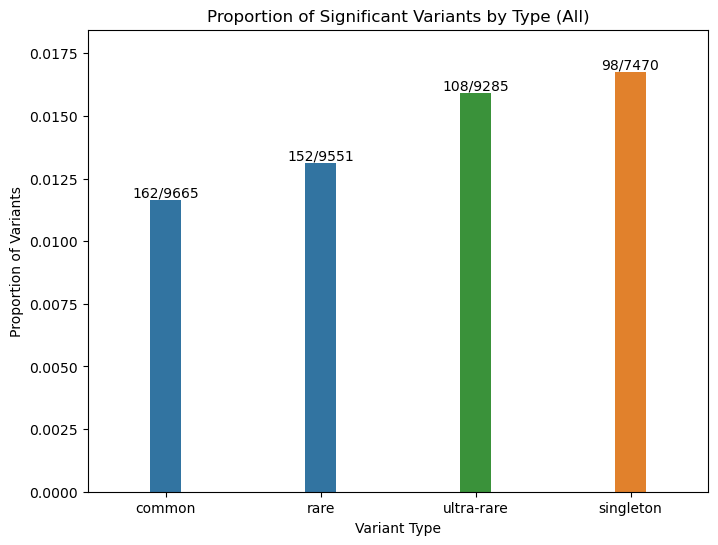

/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


  Variant Type  Proportion  Total Variants  Significant Variants
0       common    0.011960            5435                    65
1         rare    0.015145            4490                    68
2    singleton    0.016162            2908                    47
3   ultra-rare    0.019546            2865                    56


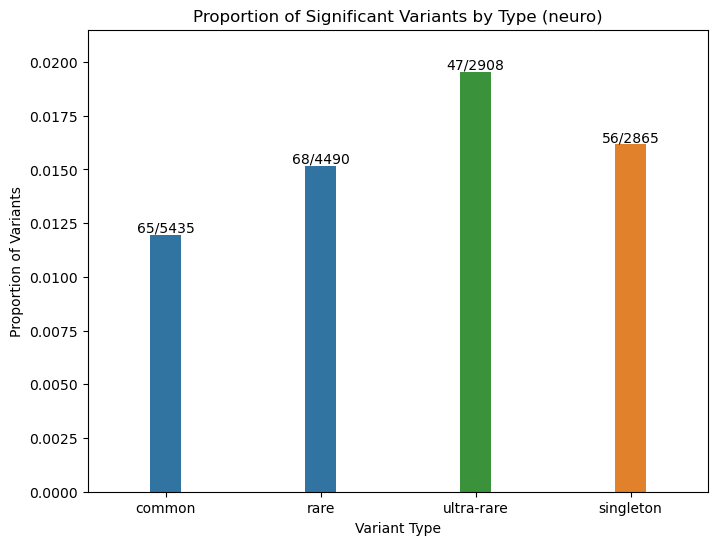

  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.018284            2680                    49
1   ultra-rare    0.015560            2635                    41
2       common    0.011577             691                     8
3         rare    0.014170             494                     7


/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


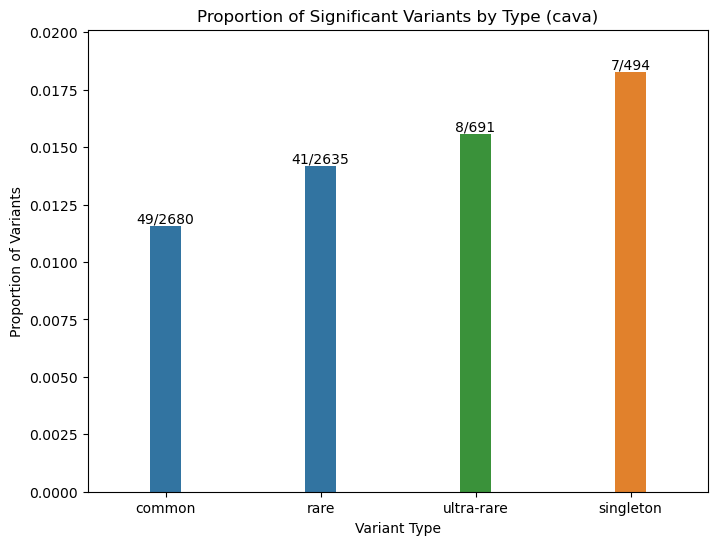

  Variant Type  Proportion  Total Variants  Significant Variants
0       common    0.010763            3159                    34
1    singleton    0.016187            2780                    45
2   ultra-rare    0.013058            2757                    36
3         rare    0.009171            2508                    23


/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


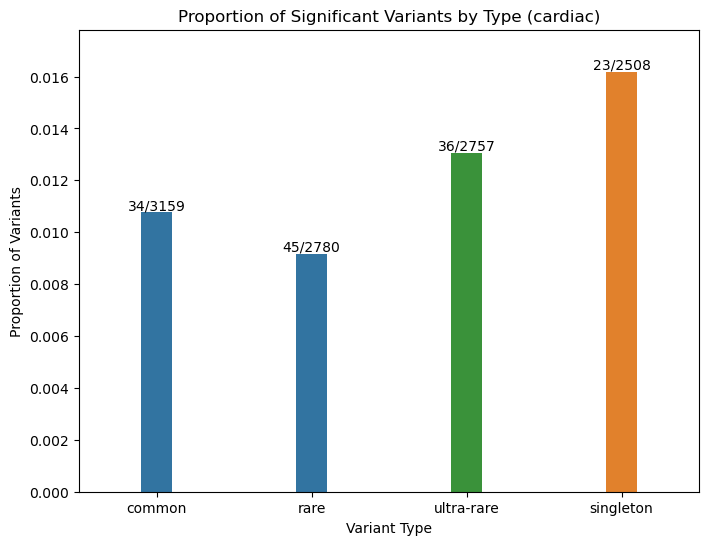

  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.016293            1473                    24
1   ultra-rare    0.014453            1453                    21
2       common    0.013652             293                     4
3         rare    0.016598             241                     4


/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_262665/546679704.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


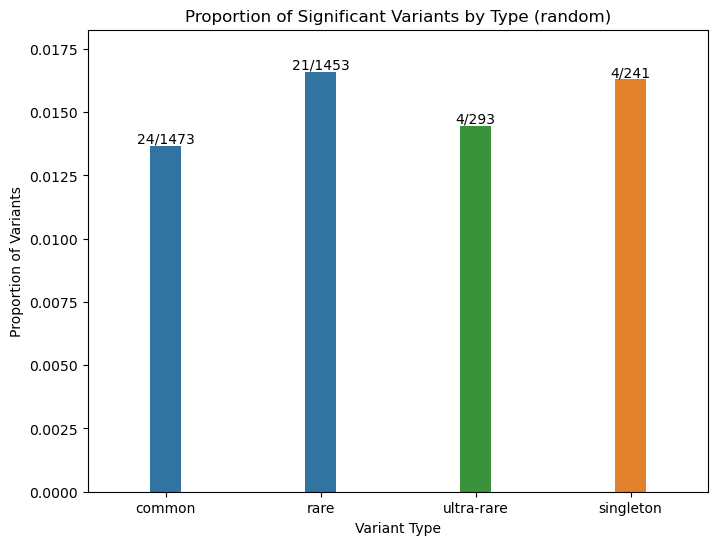

In [215]:
plot_variant_type_barplot(matched_bc_mpralm_resequencing_metadata, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'])
plot_variant_type_barplot(matched_bc_mpralm_resequencing_metadata, gene_set='neuro', x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'])
plot_variant_type_barplot(matched_bc_mpralm_resequencing_metadata, gene_set='cava', x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'])
plot_variant_type_barplot(matched_bc_mpralm_resequencing_metadata, gene_set='cardiac', x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'])
plot_variant_type_barplot(matched_bc_mpralm_resequencing_metadata, gene_set='random', x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'])

#### Neuro specific variant types

In [216]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# neuro_specific_metadata = matched_bc_mpralm_resequencing_metadata.loc[matched_bc_mpralm_resequencing_metadata['gene_set_list'].apply(lambda x: is_element_of(x, 'neuro'))]
# neuro_significant_metadata = resequencing_significant_metadata.loc[resequencing_significant_metadata['gene_set_list'].apply(lambda x: is_element_of(x, 'neuro'))]



# # Calculate the counts for all variants
# total_variant_counts = neuro_specific_metadata['variant_type'].value_counts()

# # Calculate the counts for significant variants
# significant_variant_counts = neuro_significant_metadata['variant_type'].value_counts()

# # Calculate the ratios
# ratios = {key: significant_variant_counts[key] / total_variant_counts[key] for key in total_variant_counts.index}

# # Create a DataFrame for plotting
# df_plot = pd.DataFrame(list(ratios.items()), columns=['Variant Type', 'Proportion'])

# # Add total counts and significant counts to the DataFrame for annotation
# df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
# df_plot['Significant Variants'] = df_plot['Variant Type'].map(significant_variant_counts)

# # Sort the DataFrame by the 'Proportion' column
# df_plot = df_plot.sort_values(by='Proportion')

# # Define a custom color palette
# palette = {
#     'common': '#1f77b4',
#     'singleton': '#ff7f0e',
#     'ultra-rare': '#2ca02c'
# }

# # Plot
# plt.figure(figsize=(8, 6))  # Adjust figure size for better fit
# ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=df_plot['Variant Type'], ci=None)
# plt.title('Proportion of Significant Variants by Type')
# plt.ylabel('Proportion of Variants')
# plt.xlabel('Variant Type')
# plt.ylim(0, max(df_plot['Proportion']) * 1.1)  # Slightly higher than the max ratio for better visualization

# # Adjust the bar width
# for patch in ax.patches:
#     current_width = patch.get_width()
#     diff = current_width - 0.2  # Here 0.2 is the desired width
#     patch.set_width(0.2)
#     patch.set_x(patch.get_x() + diff * .5)

# # Annotate bars with the "number_significant/total_number"
# for i, patch in enumerate(ax.patches):
#     height = patch.get_height()
#     ax.text(
#         patch.get_x() + patch.get_width() / 2,  # x coordinate
#         height,  # y coordinate
#         f'{df_plot["Significant Variants"].iloc[i]}/{df_plot["Total Variants"].iloc[i]}',  # annotation text
#         ha='center',  # horizontal alignment
#         va='bottom'  # vertical alignment
#     )

# plt.show()

### cardiac specific variants

/tmp/ipykernel_262665/578759118.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=df_plot['Variant Type'], ci=None)
/tmp/ipykernel_262665/578759118.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=df_plot['Variant Type'], ci=None)


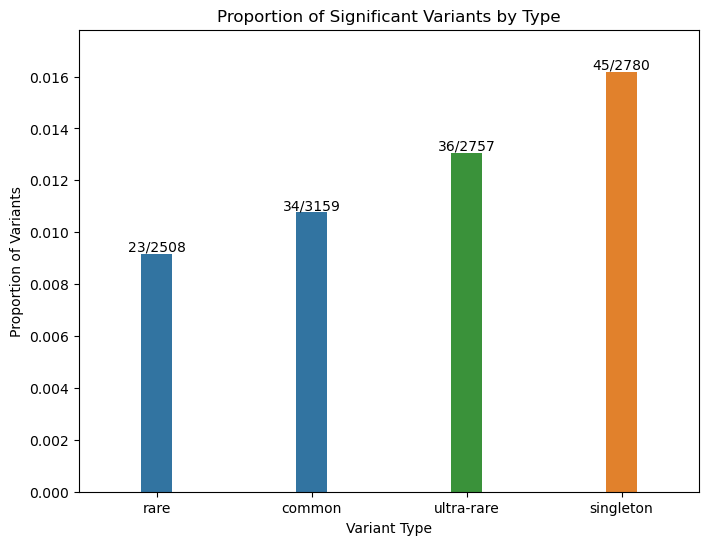

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cardiac_specific_metadata = matched_bc_mpralm_resequencing_metadata.loc[matched_bc_mpralm_resequencing_metadata['gene_set_list'].apply(lambda x: is_element_of(x, 'cardiac'))]
cardiac_significant_metadata = resequencing_significant_metadata.loc[resequencing_significant_metadata['gene_set_list'].apply(lambda x: is_element_of(x, 'cardiac'))]



# Calculate the counts for all variants
total_variant_counts = cardiac_specific_metadata['variant_type'].value_counts()

# Calculate the counts for significant variants
significant_variant_counts = cardiac_significant_metadata['variant_type'].value_counts()

# Calculate the ratios
ratios = {key: significant_variant_counts[key] / total_variant_counts[key] for key in total_variant_counts.index}

# Create a DataFrame for plotting
df_plot = pd.DataFrame(list(ratios.items()), columns=['Variant Type', 'Proportion'])

# Add total counts and significant counts to the DataFrame for annotation
df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
df_plot['Significant Variants'] = df_plot['Variant Type'].map(significant_variant_counts)

# Sort the DataFrame by the 'Proportion' column
df_plot = df_plot.sort_values(by='Proportion')

# Define a custom color palette
palette = {
    'common': '#1f77b4',
    'rare': '#1f77b4',
    'singleton': '#ff7f0e',
    'ultra-rare': '#2ca02c'
}

# Plot
plt.figure(figsize=(8, 6))  # Adjust figure size for better fit
ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=df_plot['Variant Type'], ci=None)
plt.title('Proportion of Significant Variants by Type')
plt.ylabel('Proportion of Variants')
plt.xlabel('Variant Type')
plt.ylim(0, max(df_plot['Proportion']) * 1.1)  # Slightly higher than the max ratio for better visualization

# Adjust the bar width
for patch in ax.patches:
    current_width = patch.get_width()
    diff = current_width - 0.2  # Here 0.2 is the desired width
    patch.set_width(0.2)
    patch.set_x(patch.get_x() + diff * .5)

# Annotate bars with the "number_significant/total_number"
for i, patch in enumerate(ax.patches):
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,  # x coordinate
        height,  # y coordinate
        f'{df_plot["Significant Variants"].iloc[i]}/{df_plot["Total Variants"].iloc[i]}',  # annotation text
        ha='center',  # horizontal alignment
        va='bottom'  # vertical alignment
    )

plt.show()

#### Investigate the neuro specific variants

In [218]:
common_and_enformer_variants['enformer_class_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_enformer_class_list)
common_and_enformer_variants['gene_set_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_gene_set_list)
common_and_enformer_variants['variant_type_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_variant_type_list)

In [219]:
neuro_specific_variants = common_and_enformer_variants.loc[common_and_enformer_variants['gene_set_list'].apply(lambda x: is_element_of(x, 'neuro'))]
print(f'{neuro_specific_variants.shape[0]} neuro specific variants in the table') # 31153 28.05: 30787 neuro specific variants in the table


30787 neuro specific variants in the table


#### Merge neuo specific variants to variant table
- First question: how many variants chr-pos-ref-alt are duplicated?
- Assumption variant ids of the enformer_variant table is a subset of the id from the overall 

In [220]:
variant_table['Variant_without_group'] = variant_table['Variant'].apply(split_group)

variant_neuro_metadata_table = variant_table.merge(neuro_specific_variants, left_on='Variant_without_group', right_on='ID')
merged_variant_neuro_metadata_table = variant_neuro_metadata_table.loc[~variant_neuro_metadata_table['enformer_variant_info'].isna()]
print('Neuro variants in the variant table: ', merged_variant_neuro_metadata_table.shape[0])
print('Unique neuro variants in the variant table: ', merged_variant_neuro_metadata_table['ID'].nunique())

# Neuro variants in the variant table:  19908
# Unique neuro variants in the variant table:  19833

Neuro variants in the variant table:  19908
Unique neuro variants in the variant table:  19833


Investigate tested variants which are significant and sort for high to low log2FC

In [221]:
tested_variants = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['variant_id'].str.startswith('cardiac_neuro_cava_random')]
tested_all = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['adj.P.Val'] < 0.05]
print(f'Number of all significant results: {tested_all.shape[0]}')
significant_tested = tested_variants.loc[tested_variants['adj.P.Val'] < 0.05]
print(f'Number of tested significant results: {significant_tested.shape[0]}')


Number of all significant results: 526
Number of tested significant results: 521


check for neuro specific results

In [222]:
significant_tested.dtypes

logFC                    float64
AveExpr                  float64
t                        float64
P.Value                  float64
adj.P.Val                float64
B                        float64
variant_id                object
Variant_without_group     object
label                     object
dtype: object

In [223]:
merged_variant_neuro_metadata_table.head()

,Variant,Region,REF_ID,ALT_ID,Variant_without_group,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778471|1-2179591-T-C,chr1,2179591,SKI|ENSG00000157933.11|EH38E2778471|1-2179591-T-C,T,C,1,PASS,AF=0.472883;AC=71917,1-2179591-T-C,NaN,NaN,"[(neuro, common, NA)]",[NA],[neuro],[common]
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778492|1-2192015-G-T,chr1,2192015,SKI|ENSG00000157933.11|EH38E2778492|1-2192015-G-T,G,T,1,PASS,AF=6.56901e-06;AC=1,1-2192015-G-T,11.75767,34_DNASE:K562 G2 phase,"[(neuro, singleton, enformer_random)]",[enformer_random],[neuro],[singleton]
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E1311587|1-2192366-T-G,chr1,2192366,SKI|ENSG00000157933.11|EH38E1311587|1-2192366-T-G,T,G,1,PASS,AF=6.56875e-06;AC=1,1-2192366-T-G,578.03920,470_DNASE:pancreas femal,"[(neuro, singleton, enformer_high)]",[enformer_high],[neuro],[singleton]
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A,chr1,2193142,SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A,G,A,1,PASS,AF=0.0473484;AC=7205,1-2193142-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]


In [224]:
significant_tested['Variant_without_group'] = significant_tested['variant_id'].apply(split_group)
neuro_significant_tested_metadata_table = significant_tested.merge(merged_variant_neuro_metadata_table, left_on='Variant_without_group', right_on='ID')
neuro_merged_significant_tested = neuro_significant_tested_metadata_table.loc[~neuro_significant_tested_metadata_table['enformer_variant_info'].isna()]
neuro_merged_significant_tested
print(f'{neuro_merged_significant_tested.shape[0]} neuro specific significant results')
# 236 neuro specific significant results


236 neuro specific significant results


/tmp/ipykernel_262665/717149269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_tested['Variant_without_group'] = significant_tested['variant_id'].apply(split_group)


Check neuro specifics for high variant effect results 
- Too few numbers for 95-percentile
- Take 10 top 10 bottom
- Add AF and AC

In [225]:
import re
def get_chrom_pos_ref_alt_pattern(header):
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"


def get_AF(info):
    """
    get AF from INFO: 'AF=0.0126802;AC=1930' => 0.0126802
    """
    return float(info.split(';')[0].split('=')[1])


def get_AC(info):
    """
    get AC from INFO: 'AF=0.0126802;AC=1930' => 1930
    """
    return int(info.split(';')[1].split('=')[1])

def get_variant_type(AF, AC):
    """
    get ultra-rare, common, singleton from INFO: 'AF=0.0126802;AC=1930' => common
    """
    if AF > 0.05:
        return 'common'
    elif AF > 0.01:
        return 'rare'
    elif AC == 1:
        return 'singleton'
    else:
        return 'ultra-rare'

In [226]:
common_and_enformer_variants['AF'] = common_and_enformer_variants['INFO'].apply(get_AF)
common_and_enformer_variants['AC'] = common_and_enformer_variants['INFO'].apply(get_AC)
common_and_enformer_variants['variant_type'] = common_and_enformer_variants.apply(lambda x: get_variant_type(x['AF'], x['AC']), axis=1)

In [227]:
sorted_neuro_merged_significant_tested = neuro_merged_significant_tested.sort_values(by='logFC', ascending=False)
positive_neuro_variant_effects = sorted_neuro_merged_significant_tested.head(10)
# positive_neuro_variant_effects.to_csv()
negative_neuro_variant_effects = sorted_neuro_merged_significant_tested.tail(10)
# negative_neuro_variant_effects

In [228]:
# # 0.95 percentile of logFC
# neuro_significant_tested_metadata_table['abs_log2FC'] = neuro_significant_tested_metadata_table['logFC'].abs()
# print(f'The 95-percentile of the absolute variant effect: {neuro_significant_tested_metadata_table.abs_log2FC.quantile(0.95)}')
# high_effect_neuro_significant_tested_metadata_table = neuro_significant_tested_metadata_table.loc[neuro_significant_tested_metadata_table['abs_log2FC'] >= neuro_significant_tested_metadata_table.abs_log2FC.quantile(0.95)]
# print(f'Number of results with high variant effect: {high_effect_neuro_significant_tested_metadata_table.shape[0]}')
# print(f"Number of positive effects: {high_effect_neuro_significant_tested_metadata_table.loc[high_effect_neuro_significant_tested_metadata_table['logFC']>0].shape[0]}")
# print(f"Number of negative effects: {high_effect_neuro_significant_tested_metadata_table.loc[high_effect_neuro_significant_tested_metadata_table['logFC']<0].shape[0]}")
# high_effect_neuro_significant_tested_metadata_table.sort_values(by='logFC')

# # add gene_set information
# high_effect_significant_tested_metadata = high_effect_significant_tested.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID', how='left')
# high_effect_significant_tested_metadata['gene_set_list'].value_counts()
# high_effect_significant_tested_metadata['enformer_class_list'].value_counts()

This is not the right place to load this table

In [229]:
path = '/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/high_effect_variants_new_resequencing.tsv'
high_effect_variants = pd.read_csv(path, sep="\t")
high_effect_variants['variant_type'].value_counts()
# high_effect_variants['gene_set_list'].value_counts()

variant_type
singleton    13
ulra-rare     9
common        5
Name: count, dtype: int64

In [230]:
def pos_or_neg(logFC):
    if logFC >= 0:
        return 'pos'
    return 'neg'

In [231]:
significant_tested_metadata = significant_tested.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID', how='left')

In [232]:
significant_tested_metadata
significant_tested_metadata['pos_neg'] = significant_tested_metadata['logFC'].apply(pos_or_neg)

# significant_tested_metadata.groupby('variant_type')['']
significant_tested_metadata.groupby('variant_type')['pos_neg'].value_counts()

variant_type  pos_neg
common        neg        60
              pos        48
rare          pos        51
              neg        47
singleton     pos        87
              neg        75
ultra-rare    pos        83
              neg        69
Name: count, dtype: int64

In [233]:
high_effect_variants['gene_set_list'].value_counts()
high_effect_variants.columns
high_effect_variants['pos_neg'] = high_effect_variants['logFC'].apply(pos_or_neg)
high_effect_variants.groupby('variant_type')['pos_neg'].value_counts()

variant_type  pos_neg
common        neg        3
              pos        2
singleton     pos        8
              neg        5
ulra-rare     neg        6
              pos        3
Name: count, dtype: int64

In [234]:
# 0.95 percentile of logFC
significant_tested['abs_log2FC'] = significant_tested['logFC'].abs()
print(f'The 95-percentile of the absolute variant effect: {significant_tested.abs_log2FC.quantile(0.95)}')
high_effect_significant_tested = significant_tested.loc[significant_tested['abs_log2FC'] >= significant_tested.abs_log2FC.quantile(0.95)]
print(f'Number of results with high variant effect: {high_effect_significant_tested.shape[0]}')
print(f"Number of positive effects: {high_effect_significant_tested.loc[high_effect_significant_tested['logFC']>0].shape[0]}")
print(f"Number of negative effects: {high_effect_significant_tested.loc[high_effect_significant_tested['logFC']<0].shape[0]}")
high_effect_significant_tested.sort_values(by='logFC')

# add gene_set information
high_effect_significant_tested_metadata = high_effect_significant_tested.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID', how='left')
high_effect_significant_tested_metadata['gene_set_list'].value_counts()
high_effect_significant_tested_metadata['enformer_class_list'].value_counts()
# top and bottom 3

The 95-percentile of the absolute variant effect: 1.14001713330545
Number of results with high variant effect: 27
Number of positive effects: 13
Number of negative effects: 14


/tmp/ipykernel_262665/4087893512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_tested['abs_log2FC'] = significant_tested['logFC'].abs()


enformer_class_list
[enformer_high]      21
[NA]                  5
[enformer_random]     1
Name: count, dtype: int64

In [235]:
high_effect_significant_tested.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label,abs_log2FC
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random,1.482729
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random,1.521560
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random,1.489524
6,-1.381050,0.863831,-11.778501,6.631645e-28,3.476308e-24,51.747556,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,cardiac_neuro_cava_random,1.381050
7,-1.141630,-0.187319,-11.244028,8.433980e-27,3.868456e-23,49.669666,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E3101219|14-6816...,cardiac_neuro_cava_random,1.141630


In [236]:
# high_effect_significant_tested_metadata.to_csv('high_effect_variants_new_resequencing.tsv', sep="\t", index=False)

In [237]:
high_effect_significant_tested_metadata.variant_type.value_counts()

variant_type
singleton     13
ultra-rare     9
common         3
rare           2
Name: count, dtype: int64

In [238]:
significant_tested.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label,abs_log2FC
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random,1.482729
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random,1.521560
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random,1.489524
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random,0.870725
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random,1.027577


Low number of matching IDs between enformer file and variant region map (matching header problem?)
- What variants are not in the variant region file?

In [239]:
# common_and_enformer_variants['ID'].apply(hf.)

In [240]:
common_and_enformer_variants
variant_metadata_table = variant_table.merge(neuro_specific_variants, left_on='Variant_without_group', right_on='ID')


In [241]:
metadata_variant_table = neuro_specific_variants.merge(variant_table, right_on='Variant_without_group', left_on='ID')

In [242]:
metadata_variant_table

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,Variant,Region,REF_ID,ALT_ID,Variant_without_group
0,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A
1,chr1,2193142,SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A,G,A,1,PASS,AF=0.0473484;AC=7205,1-2193142-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A
2,chr1,2194344,SKI|ENSG00000157933.11|EH38E2778498|1-2194344-T-G,T,G,1,AS_VQSR,AF=0.0215517;AC=60,1-2194344-T-G,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778498|1-2194344-T-G
3,chr1,2203222,SKI|ENSG00000157933.11|EH38E2778513|1-2203222-G-A,G,A,1,PASS,AF=0.0112207;AC=1708,1-2203222-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778513|1-2203222-G-A
4,chr1,2209048,SKI|ENSG00000157933.11|EH38E2778530|1-2209048-G-A,G,A,1,PASS,AF=0.0318423;AC=4845,1-2209048-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778530|1-2209048-G-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19903,chr1,43454876,SZT2|ENSG00000198198.17|EH38E2807393|1-4345487...,G,A,1,PASS,AF=1.31409e-05;AC=2,1-43454876-G-A,-2.065445,24_DNASE:HeLa-S3 treate,"[(neuro, ultra-rare, enformer_low)]",[enformer_low],[neuro],[ultra-rare],cardiac_neuro_cava_random:SZT2|ENSG00000198198...,cardiac_neuro_cava_random:SZT2|ENSG00000198198...,cardiac_neuro_cava_random:REF_SZT2|ENSG0000019...,cardiac_neuro_cava_random:ALT_SZT2|ENSG0000019...,SZT2|ENSG00000198198.17|EH38E2807393|1-4345487...
19904,chr13,114353586,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,G,T,1,PASS,AF=1.43841e-05;AC=2,13-114353586-G-T,-3.867383,245_DNASE:upper lobe of,"[(neuro, ultra-rare, enformer_low)]",[enformer_low],[neuro],[ultra-rare],cardiac_neuro_cava_random:CHAMP1|ENSG000001988...,cardiac_neuro_cava_random:CHAMP1|ENSG000001988...,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...
19905,chr13,114353589,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,C,T,1,PASS,AF=0.0054353;AC=807,13-114353589-C-T,-4.061413,10_DNASE:H54,"[(neuro, ultra-rare, enformer_low)]",[enformer_low],[neuro],[ultra-rare],cardiac_neuro_cava_random:CHAMP1|ENSG000001988...,cardiac_neuro_cava_random:CHAMP1|ENSG000001988...,cardiac_neuro_cava_random:REF_CHAMP1|ENSG00000...,cardiac_neuro_cava_random:ALT_CHAMP1|ENSG00000...,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...
19906,chr13,114353565,CHAMP1|ENSG00000198824.8|EH38E3085024|13-11435...,G,A,1,PASS,AF=0.000656461;AC=94,13-114353565-G-A,-4.372175,550_DNASE:right kidney m,"[(neuro, ultra-rare, enformer_low)]",[enformer_low],[neuro],[ultra-rare],cardiac_neuro

In [243]:
variant_table.shape[0]

47044

In [244]:
neuro_specific_variants.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,1-2177753-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,1-2180660-T-C,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,1-2182832-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,1-2191284-C-G,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]


#### Add AF to the results table (not useful but might be useful to interact with vcf files)


In [245]:
# vcf_file = pd.read_csv(config['files']['final_design']['vcf_file'], sep="\t", comment="#", header=None)
# vcf_file.columns = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
# vcf_file['chr_pos_ref_alt'] = vcf_file['ID'].apply(get_chrom_pos_ref_alt_pattern)
# vcf_file['chr_pos_ref_alt'].nunique() # 45738
# vcf_file['chr_pos_ref_alt'].shape[0] # 46143

#### Can only match about chr_pos_ref_alt
- check for uniqueness
- 900 duplicates in the enformer file (chr_pos_ref_alt)

- found duplicated line (1-156041147-G-A)

In [246]:
35000 - 34253

747

In [247]:
# TODO: explode here and remove duplicated variants (Why?)
common_and_enformer_variants.columns
common_and_enformer_variants = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t")
common_and_enformer_variants['enformer_variant_info'] = common_and_enformer_variants['enformer_variant_info'].apply(literal_eval) # read as list
common_and_enformer_variants['variant_type_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_variant_type_list)
common_and_enformer_variants['enformer_class_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_enformer_class_list)
common_and_enformer_variants['variant_type'] = common_and_enformer_variants['variant_type_list'].apply(extract_from_list)
common_and_enformer_variants['gene_set_list'] = common_and_enformer_variants['enformer_variant_info'].apply(get_gene_set_list)
enformer_prioritized_variants = common_and_enformer_variants.loc[common_and_enformer_variants['variant_type_list'].apply(lambda x: True if (is_element_of(x, 'ultra-rare') or is_element_of(x, 'singleton')) else False)]


In [248]:
enformer_prioritized_variants['enformer_variant_info_string'] = enformer_prioritized_variants['enformer_variant_info'].apply(str)
enformer_prioritized_variants['enformer_variant_info_string']

/tmp/ipykernel_262665/3793557978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enformer_prioritized_variants['enformer_variant_info_string'] = enformer_prioritized_variants['enformer_variant_info'].apply(str)


34122          [('cardiac', 'singleton', 'enformer_high')]
34123          [('cardiac', 'singleton', 'enformer_high')]
34124          [('cardiac', 'singleton', 'enformer_high')]
34125    [('cardiac', 'singleton', 'enformer_high'), ('...
34126          [('cardiac', 'singleton', 'enformer_high')]
                               ...                        
68217           [('random', 'ultra-rare', 'enformer_low')]
68218           [('random', 'ultra-rare', 'enformer_low')]
68219           [('random', 'ultra-rare', 'enformer_low')]
68220           [('random', 'ultra-rare', 'enformer_low')]
68221           [('random', 'ultra-rare', 'enformer_low')]
Name: enformer_variant_info_string, Length: 34100, dtype: object

In [249]:
enformer_prioritized_variants

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,variant_type_list,enformer_class_list,variant_type,gene_set_list,enformer_variant_info_string
34122,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,1,PASS,AF=6.57168e-06;AC=1,6-43797164-G-A,4254.341000,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34123,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,1,PASS,AF=6.56866e-06;AC=1,18-3059465-T-C,4022.599600,"177_DNASE:CD8-positive,","[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34124,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,1,PASS,AF=6.57618e-06;AC=1,6-43797016-G-A,3591.831000,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34125,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,12-2616967-C-A,2754.770500,401_DNASE:common myeloid,"[(cardiac, singleton, enformer_high), (neuro, ...",[singleton],[enformer_high],singleton,"[cardiac, neuro]","[('cardiac', 'singleton', 'enformer_high'), ('..."
34126,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,1,PASS,AF=6.56978e-06;AC=1,7-151848098-A-C,2746.327100,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68217,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,2-219219689-T-G,-0.586787,31_DNASE:iPS-NIHi11 mal,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68218,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,19-48747089-C-T,-0.961862,90_DNASE:HeLa-S3 G1b ph,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68219,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,2-210475933-C-A,-0.964058,665_DNASE:testis male ad,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68220,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,2-210477091-C-T,-1.122092,170_DNASE:iPS DF 4.7 mal,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"


In [250]:
# remove duplicated lines: based on an important subset of columns (DNase_max sometimes slightly different)
# explode here

enformer_prio_variants_without_duplicated_rows = enformer_prioritized_variants.drop_duplicates(subset=['ID', 'enformer_variant_info_string'], keep='first')
enformer_prio_variants_without_duplicated_rows # 34253 (found 747 duplicated rows)


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,variant_type_list,enformer_class_list,variant_type,gene_set_list,enformer_variant_info_string
34122,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,1,PASS,AF=6.57168e-06;AC=1,6-43797164-G-A,4254.341000,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34123,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,1,PASS,AF=6.56866e-06;AC=1,18-3059465-T-C,4022.599600,"177_DNASE:CD8-positive,","[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34124,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,1,PASS,AF=6.57618e-06;AC=1,6-43797016-G-A,3591.831000,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
34125,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,12-2616967-C-A,2754.770500,401_DNASE:common myeloid,"[(cardiac, singleton, enformer_high), (neuro, ...",[singleton],[enformer_high],singleton,"[cardiac, neuro]","[('cardiac', 'singleton', 'enformer_high'), ('..."
34126,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,1,PASS,AF=6.56978e-06;AC=1,7-151848098-A-C,2746.327100,392_DNASE:CD14-positive,"[(cardiac, singleton, enformer_high)]",[singleton],[enformer_high],singleton,[cardiac],"[('cardiac', 'singleton', 'enformer_high')]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68217,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,2-219219689-T-G,-0.586787,31_DNASE:iPS-NIHi11 mal,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68218,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,19-48747089-C-T,-0.961862,90_DNASE:HeLa-S3 G1b ph,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68219,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,2-210475933-C-A,-0.964058,665_DNASE:testis male ad,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"
68220,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,2-210477091-C-T,-1.122092,170_DNASE:iPS DF 4.7 mal,"[(random, ultra-rare, enformer_low)]",[ultra-rare],[enformer_low],ultra-rare,[random],"[('random', 'ultra-rare', 'enformer_low')]"


Found same variant associated to different genes and to different gene_type_lists
- check how many duplicates are with same variant with same gene association

In [251]:
def get_gene_association(header_without_group):
    """ Get gene association of tested variants with type:

    'VEGFA|ENSG00000112715.26|EH38E3709352|6-43797164-G-A',
    'MYOM1|ENSG00000101605.14|EH38E3253954|18-3059465-T-C',
    'VEGFA|ENSG00000112715.26|EH38E3709352|6-43797016-G-A',
    """
    return '|'.join(header_without_group.split('|')[:3])

In [254]:
enformer_prio_variants_without_duplicated_rows['enformer_class_string'] = enformer_prio_variants_without_duplicated_rows['enformer_class_list'].apply(str)

In [255]:
enformer_prio_variants_without_duplicated_rows.loc[enformer_prio_variants_without_duplicated_rows.duplicated(subset=['chr_pos_ref_alt','enformer_class_string'], keep=False)].sort_values(by='chr_pos_ref_alt')
#
# enformer_prio_variants_without_duplicated_rows['ID'].to_list()
# VEGFA|ENSG00000112715.26|EH38E3709352|

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,variant_type_list,enformer_class_list,variant_type,gene_set_list,enformer_variant_info_string,enformer_class_string


In [256]:
enformer_prio_variants_without_duplicated_rows['gene_association'] = enformer_prio_variants_without_duplicated_rows['ID'].apply(get_gene_association)

only 4 different duplicates (without keep=False)
- 12-116214435-A-T variant from cardiac and neuro but once in enformer_random + once in enformer_low
- 3-41275463-A-G variant from cava and neuro once in enformer_random and once in enformer_high
- What should we do with them? Exclude might be the easiest

In [257]:
enformer_prio_variants_without_duplicated_rows.loc[enformer_prio_variants_without_duplicated_rows.duplicated(subset=['chr_pos_ref_alt', 'gene_association'], keep=False)].sort_values(by='chr_pos_ref_alt')


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,variant_type_list,enformer_class_list,variant_type,gene_set_list,enformer_variant_info_string,enformer_class_string,gene_association


Found out that I do a misstake in the enformer class anotation: first merge before appending the enformer class for the gene-set

In [259]:
enformer_prio_variants_without_duplicated_rows['enformer_class_string'].value_counts()

enformer_class_string
['enformer_high']                       23810
['enformer_random']                      5248
['enformer_low']                         5040
['enformer_random', 'enformer_high']        1
['enformer_low', 'enformer_random']         1
Name: count, dtype: int64

In [262]:
enformer_prioritized_variants.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'variant_type_list', 'enformer_class_list', 'variant_type',
       'gene_set_list', 'enformer_variant_info_string'],
      dtype='object')

In [263]:
# enformer_prioritized_variants.loc[enformer_prioritized_variants[['chr_pos_ref_alt', 'gene_set_list']].duplicated()] # 749
enformer_prioritized_variants.loc[enformer_prioritized_variants[['chr_pos_ref_alt', 'gene_set_list', 'DNase_max', 'max_col']].duplicated()] # 469
enformer_prioritized_variants.loc[enformer_prioritized_variants[['chr_pos_ref_alt', 'gene_set_list', 'DNase_max', 'max_col', 'enformer_class']].duplicated()] # 467
enformer_prioritized_variants.loc[enformer_prioritized_variants[['ID', 'gene_set_list', 'DNase_max', 'max_col', 'enformer_class']].duplicated()] # 467
# enformer_prioritized_variants.loc[enformer_prioritized_variants[['chr_pos_ref_alt', 'gene_set_list', 'enformer_class', 'max_col']].duplicated()] # 747
enformer_prioritized_variants.loc[enformer_prioritized_variants[['ID', 'gene_set_list']].duplicated(keep=False)].sort_values(by='chr_pos_ref_alt') # keep=False: 1477

TypeError: unhashable type: 'list'

In [ ]:
enformer_prioritized_variants[enformer_prioritized_variants['chr_pos_ref_alt'].duplicated()] # 900 same

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type_list,DNase_max,max_col,enformer_class,chr_pos_ref_alt
10015,chr1,156124748.0,LMNA|ENSG00000160789.24|EH38E1387661|1-1561247...,G,C,1.0,PASS,AF=6.57307e-06;AC=1,singleton,"['cardiac', 'cava']",1504.938200,"177_DNASE:CD8-positive,",enformer_high,1-156124748-G-C
10016,chr1,156156383.0,LMNA|ENSG00000160789.24|EH38E2840566|1-1561563...,C,T,1.0,PASS,AF=6.57108e-06;AC=1,singleton,"['cardiac', 'cava']",1496.744800,588_DNASE:hematopoietic,enformer_high,1-156156383-C-T
10029,chr1,156150903.0,LMNA|ENSG00000160789.24|EH38E2840557|1-1561509...,G,T,1.0,PASS,AF=6.57454e-06;AC=1,singleton,"['cardiac', 'cava']",1260.145100,392_DNASE:CD14-positive,enformer_high,1-156150903-G-T
10054,chr1,156106910.0,LMNA|ENSG00000160789.24|EH38E1387629|1-1561069...,T,C,1.0,PASS,AF=6.57255e-06;AC=1,singleton,"['cardiac', 'cava']",1013.583000,"177_DNASE:CD8-positive,",enformer_high,1-156106910-T-C
10055,chr16,2015389.0,TSC2|ENSG00000103197.18|EH38E3162684|16-201538...,C,T,1.0,PASS,AF=6.57687e-06;AC=1,singleton,"['cardiac', 'cava', 'neuro']",1011.779360,392_DNASE:CD14-positive,enformer_high,16-2015389-C-T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34963,chr19,49593164.0,RRAS|ENSG00000126458.4|EH38E3313455|19-4959316...,C,T,1.0,PASS,AF=5.27009e-05;AC=8,ultra-rare,['cardiac'],0.489518,145_DNASE:SK-N-MC,enformer_low,19-49593164-C-T
34969,chr17,31235195.0,NF1|ENSG00000196712.20|EH38E1855974|17-3123519...,G,C,1.0,PASS,AF=1.31463e-05;AC=2,ultra-rare,"['cardiac', 'neuro']",0.455372,35_DNASE:K562 G1 phase,enformer_low,17-31235195-G-C
34979,chr15,78861018.0,ADAMTS7|ENSG00000136378.15|EH38E3148966|15-788...,C,T,1.0,PASS,AF=1.45283e-05;AC=2,ultra-rare,['cardiac'],0.342620,665_DNASE:testis male ad,enformer_low,15-78861018-C-T
34980,chr1,114716394.0,NRAS|ENSG00000213281.5|EH38E2832521|1-11471639...,C,A,1.0,PASS,AF=7.2317e-05;AC=11,ultra-rare,['cardiac'],0.313606,9_DNASE:frontal cortex,enformer_low,1-114716394-C-A


### Journey to baseline activity: quick check if mohans file can be merged easily to the design fasta (see /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/create_new_averaging_enformer.ipynb)
0. And make median of rows which are neuro related
- subset of columns with neuro specific
1. merge with design fasta
2. get all the references 
3. get the references of significant results
4. look at the difference in prediction between significant references and non-significant references

#### Preparing the enformer file (neuron specific and join with design fasta)
- H1 specific

In [ ]:
design_fa = hf.fasta_to_dataframe(config['files']['final_design']['design_fasta'])

In [ ]:
# subset of columns: https://stackoverflow.com/questions/31551412/how-to-select-dataframe-columns-based-on-partial-matching
neuron_words = ['cerebellum', 'frontal cortex', 'hippocampus', 'spinal cord', 'brain']
dnase_specific = ['DNASE']

In [ ]:
enformer_baseline_predictions_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/sequences_for_enformer_predictions_only_sequences_with_padding_680.tsv'
enformer_baseline_predictions = pd.read_csv(enformer_baseline_predictions_path, sep="\t")
enformer_baseline_predictions.head()

##### Prediction of only h1 column
- 'DNASE:neural stem progenitor cell originated from H1-hESC'

In [ ]:
# output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/H1_neural_stem_progenitor_enformer_dnase.tsv.gz'
# # output_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase.tsv.gz'
# enformer_baseline_predictions[['id', 'DNASE:neural stem progenitor cell originated from H1-hESC']].to_csv(output_path, sep="\t", index=False, compression='gzip')
# enformer_baseline_predictions.columns.get_loc("DNASE:neural stem progenitor cell originated from H1-hESC")

306

##### Prediction of neuro specific DNase tracks

In [ ]:
enformer_baseline_predictions.rename(columns={'id':'DNASE:very brain specific header'}, inplace=True)
enformer_baseline_predictions.head()

,DNASE:very brain specific header,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:chorion,DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour,DNASE:GM03348,DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days,DNASE:AG08395,DNASE:AG08396,DNASE:AG20443,...,DNASE:inferior parietal cortex male adult (84 years),DNASE:kidney capillary endothelial cell female embryo (113 days),DNASE:placenta male embryo (91 day),DNASE:right kidney male embryo (115 days),DNASE:coronary artery female adult (51 year),ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC,ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK,ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega,ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC,ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1961,0.0943,0.1697,0.3024,0.1082,0.1418,0.1290,0.1539,0.2046,...,0.0463,0.1087,0.2370,0.1261,0.1644,2.3822,1.5600,3.0842,0.9669,1.1727
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1233,0.0770,0.0882,0.1016,0.0693,0.1034,0.0692,0.0897,0.1155,...,0.0313,0.0726,0.0726,0.0947,0.1309,1.8988,0.9468,1.4994,1.0074,1.0907
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0222,0.0164,0.0198,0.0309,0.0163,0.0195,0.0206,0.0223,0.0275,...,0.0263,0.0566,0.0589,0.0745,0.0991,1.8352,0.9056,1.6134,0.6954,0.7274
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2126,0.0995,0.1080,0.2529,0.0863,0.1357,0.0901,0.1196,0.1660,...,0.0568,0.0999,0.1362,0.2760,0.1561,3.4291,1.2551,2.1055,5.2447,2.2171
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1063,0.0846,0.1128,0.1429,0.0857,0.1218,0.1089,0.1085,0.1485,...,0.0459,0.1001,0.1138,0.1452,0.1629,2.4780,1.3756,3.0101,1.3488,1.7251


In [ ]:
enformer_baseline_predictions.columns

Index(['DNASE:very brain specific header',
       'DNASE:cerebellum male adult (27 years) and male adult (35 years)',
       'DNASE:frontal cortex male adult (27 years) and male adult (35 years)',
       'DNASE:chorion',
       'DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour',
       'DNASE:GM03348',
       'DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days',
       'DNASE:AG08395', 'DNASE:AG08396', 'DNASE:AG20443',
       ...
       'DNASE:inferior parietal cortex male adult (84 years)',
       'DNASE:kidney capillary endothelial cell female embryo (113 days)',
       'DNASE:placenta male embryo (91 day)',
       'DNASE:right kidney male embryo (115 days)',
       'DNASE:coronary artery female adult (51 year)',
       'ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC',
       'ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK',
       'ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega',
       'ATAC:BM1077-MCP / Bone

In [ ]:
neuron_words

['cerebellum', 'frontal cortex', 'hippocampus', 'spinal cord', 'brain']

In [ ]:
'|'.join(neuron_words)

'cerebellum|frontal cortex|hippocampus|spinal cord|brain'

In [ ]:
brain_specific_enformer_predictions = enformer_baseline_predictions[enformer_baseline_predictions.columns[enformer_baseline_predictions.columns.to_series().str.contains('|'.join(neuron_words) + '|(&DNASE)')]]
brain_specific_enformer_predictions.rename(columns={'DNASE:very brain specific header':'ID'}, inplace=True)

/tmp/ipykernel_96892/2105175237.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  brain_specific_enformer_predictions = enformer_baseline_predictions[enformer_baseline_predictions.columns[enformer_baseline_predictions.columns.to_series().str.contains('|'.join(neuron_words) + '|(&DNASE)')]]
/tmp/ipykernel_96892/2105175237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_specific_enformer_predictions.rename(columns={'DNASE:very brain specific header':'ID'}, inplace=True)


In [ ]:
brain_specific_enformer_predictions.head()

,ID,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:frontal cortex female adult (67 years) and female adult (80 years),DNASE:astrocyte of the hippocampus,DNASE:astrocyte of the spinal cord,DNASE:astrocyte of the cerebellum,DNASE:brain microvascular endothelial cell,DNASE:brain pericyte,DNASE:smooth muscle cell of the brain vasculature female,...,DNASE:brain embryo (56 days) and male embryo (58 days),DNASE:spinal cord female embryo (89 days),DNASE:brain male embryo (122 days),DNASE:spinal cord female embryo (113 days),DNASE:midbrain male adult (78 years) and male adult (84 years),DNASE:spinal cord male embryo (96 days),DNASE:brain female embryo (105 days),DNASE:spinal cord female embryo (59 days) and male embryo (72 days),DNASE:brain male embryo (104 days),DNASE:spinal cord female embryo (87 days)
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1961,0.0943,0.0963,0.1002,0.1154,0.0959,0.1425,0.2123,0.1796,...,0.1518,0.0672,0.0347,0.0868,0.0502,0.0691,0.0869,0.0497,0.0670,0.0571
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1233,0.0770,0.0696,0.0729,0.0669,0.0704,0.0669,0.1269,0.1018,...,0.1632,0.0976,0.0663,0.1265,0.0382,0.0961,0.1566,0.0651,0.1338,0.0890
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0222,0.0164,0.0148,0.0554,0.0845,0.0760,0.0986,0.1360,0.1080,...,0.0537,0.0363,0.0168,0.0499,0.0294,0.0399,0.0436,0.0290,0.0351,0.0319
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2126,0.0995,0.0918,0.2203,0.2068,0.2075,0.1831,0.3175,0.2537,...,0.3152,0.1676,0.0993,0.1912,0.0679,0.1536,0.1834,0.1090,0.1745,0.1570
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1063,0.0846,0.0778,0.1487,0.2205,0.2162,0.2568,0.3010,0.3256,...,0.2243,0.0985,0.0443,0.1437,0.0502,0.1040,0.1392,0.0602,0.1066,0.0926


write to file

In [ ]:
# brain_specific_enformer_predictions.to_csv('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/brain_specific_enformer_columns_30.tsv.gz', sep="\t", index=False, compression='gzip')

Try combining it with the design fasta

In [ ]:
merged_design_enformer = design_fa.merge(brain_specific_enformer_predictions, left_on='header', right_on='ID', how='left')
print('Shape of merged file: ', merged_design_enformer.shape[0])
# remove the GC_kircher because they made problems
merged_design_enformer = merged_design_enformer.loc[~merged_design_enformer['header'].str.startswith('GC_Kircher')]
print('Shape after removing the GC Kircher sequences: ', merged_design_enformer.shape[0])

Shape of merged file:  80215
Shape after removing the GC Kircher sequences:  80012


##### Problems with the GC_Kircher sequences

In [ ]:
merged_design_enformer.loc[merged_design_enformer['DNASE:astrocyte of the hippocampus'].isna()]['header'].str.startswith('GC_Kircher').sum()

0

##### Merge the predictions to the median of all the 30 colums

In [ ]:
merged_design_enformer.columns

Index(['header', 'sequence', 'ID',
       'DNASE:cerebellum male adult (27 years) and male adult (35 years)',
       'DNASE:frontal cortex male adult (27 years) and male adult (35 years)',
       'DNASE:frontal cortex female adult (67 years) and female adult (80 years)',
       'DNASE:astrocyte of the hippocampus',
       'DNASE:astrocyte of the spinal cord',
       'DNASE:astrocyte of the cerebellum',
       'DNASE:brain microvascular endothelial cell', 'DNASE:brain pericyte',
       'DNASE:smooth muscle cell of the brain vasculature female',
       'DNASE:brain female embryo (85 days)', 'DNASE:brain embryo (112 days)',
       'DNASE:spinal cord male embryo (105 days)',
       'DNASE:brain female embryo (96 days)',
       'DNASE:brain female embryo (142 days)',
       'DNASE:brain female embryo (117 days)',
       'DNASE:brain female embryo (109 days)',
       'DNASE:brain male embryo (105 days)',
       'DNASE:brain male embryo (72 days) and male embryo (76 days)',
       'DNASE:brai

In [ ]:
merged_design_enformer.head()

,header,sequence,ID,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:frontal cortex female adult (67 years) and female adult (80 years),DNASE:astrocyte of the hippocampus,DNASE:astrocyte of the spinal cord,DNASE:astrocyte of the cerebellum,DNASE:brain microvascular endothelial cell,...,DNASE:brain embryo (56 days) and male embryo (58 days),DNASE:spinal cord female embryo (89 days),DNASE:brain male embryo (122 days),DNASE:spinal cord female embryo (113 days),DNASE:midbrain male adult (78 years) and male adult (84 years),DNASE:spinal cord male embryo (96 days),DNASE:brain female embryo (105 days),DNASE:spinal cord female embryo (59 days) and male embryo (72 days),DNASE:brain male embryo (104 days),DNASE:spinal cord female embryo (87 days)
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTAAGAATACAAGTAACTGATGAATGAAGGGGG...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1961,0.0943,0.0963,0.1002,0.1154,0.0959,0.1425,...,0.1518,0.0672,0.0347,0.0868,0.0502,0.0691,0.0869,0.0497,0.0670,0.0571
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTTTGGGTATGCTGCCCCCCAGCTGGCGGGGCA...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1233,0.0770,0.0696,0.0729,0.0669,0.0704,0.0669,...,0.1632,0.0976,0.0663,0.1265,0.0382,0.0961,0.1566,0.0651,0.1338,0.0890
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTACGAGCAAGGGAATGAGAGAGAGTGGGTTAG...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0222,0.0164,0.0148,0.0554,0.0845,0.0760,0.0986,...,0.0537,0.0363,0.0168,0.0499,0.0294,0.0399,0.0436,0.0290,0.0351,0.0319
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCGTGGACACGCGTGATTGACCCTTTAACTGT...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2126,0.0995,0.0918,0.2203,0.2068,0.2075,0.1831,...,0.3152,0.1676,0.0993,0.1912,0.0679,0.1536,0.1834,0.1090,0.1745,0.1570
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCCGGAGAGTCTCAGCTCCCGCAGCCCTAACA...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1063,0.0846,0.0778,0.1487,0.2205,0.2162,0.2568,...,0.2243,0.0985,0.0443,0.1437,0.0502,0.1040,0.1392,0.0602,0.1066,0.0926


In [ ]:
merged_design_enformer['neuro_specific_DNase_median'] = merged_design_enformer.iloc[:,3:].median(axis = 1)
merged_design_enformer['neuro_specific_DNase_max'] = merged_design_enformer.iloc[:,3:].max(axis = 1)

In [ ]:
# TODO: probably want to store the merged_design_enformer
sorted_merged_design_enformer.head()

NameError: name 'sorted_merged_design_enformer' is not defined

In [ ]:
# output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/brain_specific_enformer_dnase_median_dnase_max.tsv.gz'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/brain_specific_enformer_dnase_median_dnase_max.tsv.gz'
# sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median', 'neuro_specific_DNase_max']].to_csv(output_path, sep="\t", index=False, compression='gzip')

##### Investigate prediction of DNase max
- And for neuro specific columns

In [ ]:
# wrong file:
# variant_dnase_predictions_path = "/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/variants_80k_680.tsv"
variant_dnase_predictions_path = "/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/enformer_newrun/rerun_variants_80k_680.tsv"
variant_dnase_predictions_raw = pd.read_csv(variant_dnase_predictions_path, sep="\t")
variant_dnase_predictions_raw.head()


,chrom,pos,id,ref,alt,0_DNASE:cerebellum mal,1_DNASE:frontal cortex,2_DNASE:chorion,3_DNASE:Ishikawa treat,4_DNASE:GM03348,...,665_DNASE:testis male ad,666_DNASE:transverse col,667_DNASE:right renal pe,668_DNASE:lung embryo (1,669_DNASE:inferior parie,670_DNASE:kidney capilla,671_DNASE:placenta male,672_DNASE:right kidney m,673_DNASE:coronary arter,674_ATAC:BM0106-Day0-MCP
0,chr1,2179591,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,C,-24.534307,7.420129,4.623342,3.233414,0.704759,...,1.302212,-6.703251,0.892911,5.766830,1.435593,-2.547557,-4.155036,1.067765,1.664940,0.862299
1,chr1,2191444,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,-0.192879,0.284395,0.144714,0.344883,0.241588,...,-0.092939,0.777716,-0.036971,1.074118,-0.398899,0.711352,-1.018640,-0.143923,0.186056,0.291295
2,chr1,2192015,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,T,0.150436,-2.589104,9.912368,3.370937,-2.699909,...,-0.613569,-4.681578,-3.195161,-16.274694,-1.268586,-0.253009,-5.993198,-4.505129,-7.673705,-0.453357
3,chr1,2192366,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,G,-127.368546,-7.040935,54.402786,16.821918,5.428615,...,2.670140,145.292300,59.827730,259.199650,-7.615203,14.868067,176.644260,65.624180,110.170120,-9.438206
4,chr1,2193142,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,-1.632162,5.866420,20.471125,-0.096696,1.417702,...,-0.460442,1.786885,-0.228986,7.327300,-2.774594,4.022185,-2.349382,0.165682,-0.649004,0.029709


In [ ]:
# drop unused columns
unused_columns = ['chrom', 'pos', 'ref', 'alt']
variant_dnase_predictions_all = variant_dnase_predictions_raw.drop(columns=unused_columns)

Absolute values does not make sense here use normal prediction values and use downstream the absolute value of these

In [ ]:
# Separate the non-numeric columns
non_numeric_cols = variant_dnase_predictions_all.iloc[:,:1].rename(columns={'id': 'ID'})

#dnase cols:
dnase_columns = [col for col in variant_dnase_predictions_all.columns if 'DNASE' in col]
numeric_cols = variant_dnase_predictions_all[dnase_columns]

# # Compute the absolute values for the numeric columns
# abs_numeric_cols = numeric_cols.abs()

# # Compute the row-wise maximum of the absolute values
# rowwise_max_abs = abs_numeric_cols.max(axis=1)
# rowwise_median_abs = abs_numeric_cols.median(axis=1)
# # compute row-wise max and median
rowwise_max = numeric_cols.max(axis=1)
rowwise_median = numeric_cols.median(axis=1)

# Combine the non-numeric columns back with the results
variant_dnase_predictions_computed = pd.concat([non_numeric_cols, rowwise_max.rename('variant_specific_DNase_max'), rowwise_median.rename('variant_specific_DNase_median')], axis=1)

# # write to file
enformer_variant_outpath = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_max_median.tsv.gz'
# enformer_variant_outpath = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_variant_predictions/variant_prediction_DNase_max_median.tsv.gz'
# variant_dnase_predictions_computed.to_csv(enformer_variant_outpath, sep="\t", index=False, compression='gzip')

Neuro specific

In [ ]:
variant_dnase_predictions = variant_dnase_predictions_raw.drop(columns=unused_columns).rename(columns={'id':'DNASE:very brain specific header'})
variant_dnase_predictions

,DNASE:very brain specific header,0_DNASE:cerebellum mal,1_DNASE:frontal cortex,2_DNASE:chorion,3_DNASE:Ishikawa treat,4_DNASE:GM03348,5_DNASE:GM03348 geneti,6_DNASE:AG08395,7_DNASE:AG08396,8_DNASE:AG20443,...,665_DNASE:testis male ad,666_DNASE:transverse col,667_DNASE:right renal pe,668_DNASE:lung embryo (1,669_DNASE:inferior parie,670_DNASE:kidney capilla,671_DNASE:placenta male,672_DNASE:right kidney m,673_DNASE:coronary arter,674_ATAC:BM0106-Day0-MCP
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-24.534307,7.420129,4.623342,3.233414,0.704759,1.552103,-0.644107,3.156322,1.563619,...,1.302212,-6.703251,0.892911,5.766830,1.435593,-2.547557,-4.155036,1.067765,1.664940,0.862299
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-0.192879,0.284395,0.144714,0.344883,0.241588,0.542470,-0.352739,0.161248,-0.151744,...,-0.092939,0.777716,-0.036971,1.074118,-0.398899,0.711352,-1.018640,-0.143923,0.186056,0.291295
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.150436,-2.589104,9.912368,3.370937,-2.699909,0.503934,-0.226556,-0.705747,-0.053723,...,-0.613569,-4.681578,-3.195161,-16.274694,-1.268586,-0.253009,-5.993198,-4.505129,-7.673705,-0.453357
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-127.368546,-7.040935,54.402786,16.821918,5.428615,-62.018867,50.111270,109.796715,36.675148,...,2.670140,145.292300,59.827730,259.199650,-7.615203,14.868067,176.644260,65.624180,110.170120,-9.438206
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-1.632162,5.866420,20.471125,-0.096696,1.417702,0.807081,1.731574,9.950411,1.366321,...,-0.460442,1.786885,-0.228986,7.327300,-2.774594,4.022185,-2.349382,0.165682,-0.649004,0.029709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46139,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,3.163877,2.074484,-0.091116,1.470320,3.880267,3.961866,3.611700,5.068965,3.443607,...,1.652701,2.649347,1.026470,1.412675,0.330695,1.298560,4.847085,1.053466,2.401195,0.132353
46140,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,1.493516,-4.327486,-7.309661,-15.761482,11.305547,-0.059971,18.824778,-0.921182,6.972353,...,0.643769,-5.386774,1.767433,-6.799806,-2.904181,12.611753,-6.448321,0.967050,-4.565339,8.825460
46141,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,-3.382693,-6.150816,-8.580999,-4.688692,-7.768112,-6.711224,-5.287640,-9.993103,-6.289350,...,-0.835602,-11.380106,-5.258940,-4.876058,-1.689789,-8.748643,-4.400265,-5.637239,-3.761355,0.489899
46142,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,4.348503,11.292089,2.256465,2.019877,9.344953,6.651654,6.351018,8.071921,8.027961,...,0.028711,12.959434,1.742657,2.509336,3.792117,4.732122,17.272526,1.111905,5.912749,-2.003565


Make absolute values and chose maximum of brain specific columns for the variant predictions

In [ ]:
brain_specific_varinat_enformer_predictions = variant_dnase_predictions[variant_dnase_predictions.columns[variant_dnase_predictions.columns.to_series().str.contains('|'.join(neuron_words) + '|(&DNASE)')]]
brain_specific_varinat_enformer_predictions.rename(columns={'DNASE:very brain specific header':'ID'}, inplace=True)

/tmp/ipykernel_96892/128218442.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  brain_specific_varinat_enformer_predictions = variant_dnase_predictions[variant_dnase_predictions.columns[variant_dnase_predictions.columns.to_series().str.contains('|'.join(neuron_words) + '|(&DNASE)')]]
/tmp/ipykernel_96892/128218442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_specific_varinat_enformer_predictions.rename(columns={'DNASE:very brain specific header':'ID'}, inplace=True)


In [ ]:
brain_specific_varinat_enformer_predictions['neuro_specific_variant_DNase_median'] = brain_specific_varinat_enformer_predictions.iloc[:,1:].median(axis = 1)
brain_specific_varinat_enformer_predictions['neuro_specific_variant_DNase_max'] = brain_specific_varinat_enformer_predictions.iloc[:,1:].max(axis = 1)
interesting_columns = ['ID', 'neuro_specific_variant_DNase_median', 'neuro_specific_variant_DNase_max']
enformer_variant_outpath = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_max_median_neuro_specific.tsv.gz'
enformer_variant_outpath = '/home/kisa/coding/80K_MPRA/enformer_data/enformer_variant_predictions/variant_prediction_DNase_max_median_neuro_specific.tsv.gz'
# brain_specific_varinat_enformer_predictions[interesting_columns].to_csv(enformer_variant_outpath, sep="\t", index=False, compression='gzip')
# # write brain specific variant prediction to file
# variant_dnase_predictions_computed.to_csv(enformer_variant_outpath, sep="\t", index=False, compression='gzip')

/tmp/ipykernel_96892/2766038394.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_specific_varinat_enformer_predictions['neuro_specific_variant_DNase_median'] = brain_specific_varinat_enformer_predictions.iloc[:,1:].median(axis = 1)
/tmp/ipykernel_96892/2766038394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brain_specific_varinat_enformer_predictions['neuro_specific_variant_DNase_max'] = brain_specific_varinat_enformer_predictions.iloc[:,1:].max(axis = 1)


In [ ]:
brain_specific_varinat_enformer_predictions

,ID,0_DNASE:cerebellum mal,1_DNASE:frontal cortex,9_DNASE:frontal cortex,80_DNASE:brain microvas,81_DNASE:brain pericyte,179_DNASE:brain female e,216_DNASE:brain embryo (,232_DNASE:spinal cord ma,240_DNASE:brain female e,...,499_DNASE:brain male emb,510_DNASE:spinal cord fe,524_DNASE:midbrain male,561_DNASE:spinal cord ma,580_DNASE:brain female e,619_DNASE:spinal cord fe,644_DNASE:brain male emb,662_DNASE:spinal cord fe,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-24.534307,7.420129,2.206833,-3.732093,-0.972604,-5.010064,-0.805556,0.842289,-2.340920,...,-0.241911,-0.617032,0.116017,0.319764,0.129007,0.583063,-1.920648,1.150451,0.094684,7.420129
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-0.192879,0.284395,1.274558,0.491236,0.458965,0.467644,0.297129,0.241812,0.506803,...,0.608152,0.860879,0.083536,0.589749,0.631474,0.639590,0.806929,0.626175,0.550441,1.274558
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.150436,-2.589104,-3.701647,-7.545986,-8.805666,-0.617702,0.059301,-2.601587,0.059532,...,-2.039032,-4.950263,-2.261165,-3.476060,-1.967787,-2.319481,-1.511037,-2.813472,-2.290323,1.248633
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-127.368546,-7.040935,4.762050,334.341060,170.163790,-2.341429,10.362672,6.080092,37.160690,...,37.560757,19.606632,-2.955035,-6.536174,46.587086,-15.188318,22.083822,-9.362695,5.421071,334.341060
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-1.632162,5.866420,17.665040,3.241290,-3.023432,0.790041,0.050250,-1.444985,-0.071957,...,-0.718642,-1.780249,-0.316382,-1.748154,-1.454223,-0.032869,-0.485611,-1.160814,-0.534271,17.665040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46139,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,3.163877,2.074484,1.608908,-0.231119,-0.625204,0.121616,0.297753,0.002985,-0.067039,...,-0.426290,-0.460509,-0.136520,-0.383042,-0.302559,-0.338951,-0.068175,-0.321052,-0.183820,3.163877
46140,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,1.493516,-4.327486,-1.921293,12.157541,-9.460363,1.430109,-0.436642,0.295718,1.086856,...,-0.281029,-0.631449,-6.511876,0.329045,1.579994,2.996964,1.058955,2.898676,0.726947,12.157541
46141,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,-3.382693,-6.150816,-7.029286,-6.623674,-5.846934,-2.804600,-1.221286,-2.395513,-2.179924,...,-2.367985,-3.042735,-1.473508,-2.198270,-2.479192,-3.330263,-2.553227,-2.566686,-2.793651,-1.221286
46142,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,4.348503,11.292089,0.005491,9.256871,8.425390,4.620318,3.266542,4.155493,3.888247,...,5.191542,7.418392,2.366322,4.635309,6.189118,4.763948,5.642917,3.842449,4.956140,11.292089


##### Absolute values do only make sense during prioritization

In [ ]:
# # Separate the non-numeric columns
# non_numeric_cols = brain_specific_varinat_enformer_predictions.iloc[:,:1]
# numeric_cols = brain_specific_varinat_enformer_predictions.iloc[:,1:]

# # Compute the absolute values for the numeric columns
# abs_numeric_cols = numeric_cols.abs()

# # # Compute the row-wise maximum of the absolute values
# # rowwise_max_abs = abs_numeric_cols.max(axis=1)
# # rowwise_median_abs = abs_numeric_cols.median(axis=1)
# # Compute the row-wise maximum and median of the numerical columns
# rowwise_max = numeric_cols.max(axis=1)
# rowwise_median = numeric_cols.median(axis=1)

# # Combine the non-numeric columns back with the results
# variant_dnase_predictions_computed = pd.concat([non_numeric_cols, rowwise_max_abs.rename('variant_neuro_specific_DNase_max_abs'), rowwise_median_abs.rename('variant_neuro_specific_DNase_median')], axis=1)
# variant_dnase_predictions_computed

# # # write to file
# enformer_variant_outpath = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_abs_max_median_neuro_specific.tsv.gz'
# # enformer_variant_outpath = '/home/kisa/coding/80K_MPRA/enformer_data/dnase_absolute_variant_prediction/variant_prediction_DNase_abs_max_median_neuro_specific.tsv.gz'
# variant_dnase_predictions_computed.to_csv(enformer_variant_outpath, sep="\t", index=False, compression='gzip')

These files are used for the investigation if we can identify more significant results from the random data set

##### Prediction of only h1 column (variant effect)
- 'DNASE:neural stem progenitor cell originated from H1-hESC'
- Header change in variant prediction: 305_DNASE:neural stem pr => DNASE:neural stem progenitor cell originated from H1-hESC


In [ ]:
[x for x in variant_dnase_predictions_raw.columns if 'neural' in x]

In [ ]:
output_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/H1_neural_stem_progenitor_enformer_dnase_variant.tsv.gz'
# output_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase_variant.tsv.gz'

# variant_dnase_predictions_raw[['id', '305_DNASE:neural stem pr']].to_csv(output_path, sep="\t", index=False, compression='gzip')

#### Next step: find the references of the significant variants
- variant id of the mpralm results and get REF_ID column

In [ ]:
variant_table.head()
# bc_mpralm_resequencing.head()

,Variant,Region,REF_ID,ALT_ID,Variant_without_group
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778471|1-2179591-T-C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778492|1-2192015-G-T
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E1311587|1-2192366-T-G
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A


In [ ]:
significant_results_bcmpralm = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['adj.P.Val'] < 0.05]
significant_results_bcmpralm['variant_id'].nunique()

significant_variant_table = significant_results_bcmpralm.merge(variant_table, left_on='variant_id', right_on='Variant', how='left')
significant_variant_table.head()
print(significant_variant_table.shape[0])
# print(significant_variant_table['Variant'].value_counts())

# get significant REF_IDs as one group and investigate if the prediction of enformer looks different to the values of the non-significant variants
significant_REF_IDS = significant_variant_table['REF_ID'].to_list()
print(f'Number of significant REF IDs: {len(significant_REF_IDS)}, unique: {len(set(significant_REF_IDS))}')
non_significant_REF_IDs = variant_table.loc[~variant_table['REF_ID'].isin(significant_REF_IDS)]['REF_ID'].to_list()
print('Number of non_significant REF IDs', len(non_significant_REF_IDs), ' unique: ', len(set(non_significant_REF_IDs)))
non_significant_variants = variant_table.loc[~variant_table['REF_ID'].isin(significant_REF_IDS)]
# match the non significant variants to the bc mpralm results and plot them

527
Number of significant REF IDs: 527, unique: 472
Number of non_significant REF IDs 44785  unique:  18412


Numbers für common / rare / singleton

In [ ]:
common_and_enformer_variants.gene_set_list.value_counts()

gene_set_list
[neuro]                   28869
[cardiac]                 19320
[cava]                    11688
[random]                   5956
[cardiac, neuro]           1572
[cardiac, cava]             471
[neuro, cava]               234
[cardiac, neuro, cava]      112
Name: count, dtype: int64

In [ ]:
common_and_enformer_variants.variant_type_list.value_counts()

variant_type_list
[common]        18801
[ultra-rare]    17051
[singleton]     17049
[rare]          15321
Name: count, dtype: int64

In [ ]:
common_and_enformer_variants.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,AF,AC,variant_type
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,1-2177753-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.012680,1930,rare
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,1-2180660-T-C,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.014303,2175,rare
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,1-2182832-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.045011,6841,rare
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,1-2191284-C-G,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.046652,7101,rare
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.017203,2617,rare


merge mrpa results with enformer

In [ ]:
tested_bc_mpralm_resequencing = bc_mpralm_resequencing.loc[bc_mpralm_resequencing['variant_id'].str.startswith('cardiac_neuro_cava_random')]
tested_bc_mpralm_resequencing # 36168
tested_bc_mpralm_resequencing['Variant_without_group'] = tested_bc_mpralm_resequencing['variant_id'].apply(split_group)
tested_mpralm_enformer_df = tested_bc_mpralm_resequencing.merge(common_and_enformer_variants, left_on='Variant_without_group', right_on='ID', how='left') # 36168
merged_tested_mpralm_enformer_df = tested_mpralm_enformer_df.loc[~tested_mpralm_enformer_df['enformer_variant_info'].isna()]
not_merged_tested_mpralm_enformer_df = tested_mpralm_enformer_df.loc[tested_mpralm_enformer_df['enformer_variant_info'].isna()]
# how many not merged are significant? 1
# not_merged_tested_mpralm_enformer_df.loc[not_merged_tested_mpralm_enformer_df['adj.P.Val']<0.05].shape[0]

/tmp/ipykernel_1353/1518941378.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bc_mpralm_resequencing['Variant_without_group'] = tested_bc_mpralm_resequencing['variant_id'].apply(split_group)


In [ ]:
merged_tested_mpralm_enformer_df.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label,CHROM,...,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,AF,AC,variant_type
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random,chr5,...,5-14408059-A-G,496.12640,109_DNASE:fibroblast of,"[(neuro, singleton, enformer_high)]",[enformer_high],[neuro],[singleton],0.000007,1.0,singleton
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random,chr5,...,5-14259916-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.016828,2558.0,rare
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random,chr2,...,2-219267001-T-C,116.32464,625_DNASE:K562,"[(random, singleton, enformer_high)]",[enformer_high],[random],[singleton],0.000007,1.0,singleton
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random,chr3,...,3-142578095-C-G,359.43910,"177_DNASE:CD8-positive,","[(cava, ultra-rare, enformer_high)]",[enformer_high],[cava],[ultra-rare],0.000046,7.0,ulra-rare
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random,chr16,...,16-68784390-A-G,655.28420,380_DNASE:foreskin melan,"[(cava, singleton, enformer_high)]",[enformer_high],[cava],[singleton],0.000007,1.0,singleton


After mprasnakeflow and MPRAlm

variant type

In [ ]:
merged_tested_mpralm_enformer_df # 35971
merged_tested_mpralm_enformer_df.loc[merged_tested_mpralm_enformer_df['adj.P.Val']<0.05].shape[0] # 520
merged_tested_mpralm_enformer_df['variant_type_list'].value_counts()

variant_type_list
[singleton]     9665
[ultra-rare]    9551
[common]        9285
[rare]          7470
Name: count, dtype: int64

enformer class

In [ ]:
merged_tested_mpralm_enformer_df

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant_without_group,label,CHROM,...,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,AF,AC,variant_type
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random,chr5,...,5-14408059-A-G,496.12640,109_DNASE:fibroblast of,"[(neuro, singleton, enformer_high)]",[enformer_high],[neuro],[singleton],0.000007,1.0,singleton
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random,chr5,...,5-14259916-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.016828,2558.0,rare
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random,chr2,...,2-219267001-T-C,116.32464,625_DNASE:K562,"[(random, singleton, enformer_high)]",[enformer_high],[random],[singleton],0.000007,1.0,singleton
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random,chr3,...,3-142578095-C-G,359.43910,"177_DNASE:CD8-positive,","[(cava, ultra-rare, enformer_high)]",[enformer_high],[cava],[ultra-rare],0.000046,7.0,ulra-rare
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random,chr16,...,16-68784390-A-G,655.28420,380_DNASE:foreskin melan,"[(cava, singleton, enformer_high)]",[enformer_high],[cava],[singleton],0.000007,1.0,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36163,0.000845,-0.069064,0.012114,9.903371e-01,9.977055e-01,-6.829936,cardiac_neuro_cava_random:NCOA1|ENSG0000008467...,NCOA1|ENSG00000084676.16|EH38E1980646|2-245846...,cardiac_neuro_cava_random,chr2,...,2-24584664-C-T,NaN,NaN,"[(neuro, common, NA)]",[NA],[neuro],[common],0.891901,135667.0,common
36164,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,TMEM70|ENSG00000175606.11|EH38E3840361|8-74003...,cardiac_neuro_cava_random,chr8,...,8-74003769-C-G,370.75873,588_DNASE:hematopoietic,"[(cardiac, singleton, enformer_high)]",[enformer_high],[cardiac],[singleton],0.000007,1.0,singleton
36165,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,CHD7|ENSG00000171316.14|EH38E3836279|8-6077768...,cardiac_neuro_cava_random,chr8,...,8-60777684-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare],0.021523,3273.0,rare
36166,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,GATA4|ENSG00000136574.19|EH38E2611158|8-118060...,cardiac_neuro_cava_random,chr8,...,8-11806038-T-C,NaN,NaN,"[(cardiac, rare, NA)]",[NA],[cardiac],[rare],0.011074,1685.0,rare


In [ ]:
merged_tested_mpralm_enformer_df['enformer_class_list'].value_counts()

enformer_class_list
[NA]                                16755
[enformer_high]                     14094
[enformer_random]                    2736
[enformer_low]                       2384
[enformer_random, enformer_high]        1
[enformer_low, enformer_random]         1
Name: count, dtype: int64

In [ ]:
merged_tested_mpralm_enformer_df['gene_set_list'].value_counts()

gene_set_list
[neuro]             14922
[cardiac]           10415
[cava]               6283
[random]             3460
[cardiac, neuro]      674
[cardiac, cava]       115
[neuro, cava]         102
Name: count, dtype: int64

In [ ]:
random

NameError: name 'random' is not defined

In [ ]:
46 + 69 + 102 + 6283

6500

In [ ]:
10415 + 674 + 69 + 46

11204

In [ ]:
674 + 102 + 14922 # neuro

15698

significant

In [ ]:
significant_merged_tested_mpralm_enformer_df = merged_tested_mpralm_enformer_df.loc[merged_tested_mpralm_enformer_df['adj.P.Val']<0.05] # 520
significant_merged_tested_mpralm_enformer_df['variant_type_list'].value_counts()



variant_type_list
[common]        206
[singleton]     162
[ultra-rare]    152
Name: count, dtype: int64

In [ ]:
significant_merged_tested_mpralm_enformer_df['enformer_class_list'].value_counts()

enformer_class_list
[enformer_high]      263
[NA]                 206
[enformer_random]     31
[enformer_low]        20
Name: count, dtype: int64

In [ ]:
significant_merged_tested_mpralm_enformer_df['gene_set_list'].value_counts()

gene_set_list
[neuro]             228
[cardiac]           126
[cava]              101
[random]             53
[cardiac, neuro]      8
[cardiac, cava]       2
[cava, cardiac]       2
Name: count, dtype: int64

In [ ]:
228 + 8 # neuro

236

In [ ]:
126 + 8 + 2 + 2

138

In [ ]:
significant_high = 263
significant_not_high = 31+20
all_high = 14094
all_not_high = 2736 + 2384
all_values = all_high + all_not_high


total_sig = 263 + 31 + 20
total_non_sig = 14094 + 2736 + 2384 + 2 - total_sig
total_high = all_high
total_non_high = all_not_high
table_total = 14094 + 2736 + 2384 + 2

In [ ]:
table_total
total_sig

314

In [ ]:
# test with chi-square
from scipy.stats import chisquare
observed = [significant_high, significant_not_high, all_high-significant_high, all_not_high-significant_not_high]
expected = [total_sig * total_high / table_total, total_sig * total_non_high / table_total, total_non_sig * total_high / table_total, total_non_sig * total_non_high / table_total]

chisquare(observed, expected) # Power_divergenceResult(statistic=17.683255607490718, pvalue=0.0005112133718720527)
# print('interpretation: enformer has a huge number of false positives.')
# print('This means the distribution of significant results in the enformer class file is significantly different from the distribution of all results in the enformer class file.')


Power_divergenceResult(statistic=17.683255607490718, pvalue=0.0005112133718720527)

precision recall of enformer high

In [ ]:
recall_enformer = significant_high / total_sig
recall_enformer

0.8375796178343949

In [ ]:
precision_enformer = significant_high / all_high
precision_enformer

0.018660422874982263

enformer low predictions:

In [ ]:
enformer_class_list
[NA]                                16755
[enformer_high]                     14094
[enformer_random]                    2736
[enformer_low]                       2384
[enformer_random, enformer_high]        1
[enformer_low, enformer_random]         1

In [ ]:
enformer_class_list (significant)
[enformer_high]      263
[NA]                 206
[enformer_random]     31
[enformer_low]        20

In [ ]:
significant_high = 2384 - 20 # non_significant_low
significant_not_high = 14094 + 2736 + 1 - 263 - 31 # non_significant not_low (all values not low - significant not low)
all_high = 2384 # all_low
all_not_high = 14094 + 2736 + 1 # all_not_low
all_values = all_high + all_not_high


total_sig = 14094 + 2736 + 2384 + 2 - 263 - 20 - 31 # total non-significant
total_non_sig = 263 + 31 + 20 # total significant
total_high = all_high
total_non_high = all_not_high
table_total = 14094 + 2736 + 2384 + 2 # all

In [ ]:
# test with chi-square
from scipy.stats import chisquare
observed = [significant_high, significant_not_high, all_high-significant_high, all_not_high-significant_not_high]
expected = [total_sig * total_high / table_total, total_sig * total_non_high / table_total, total_non_sig * total_high / table_total, total_non_sig * total_non_high / table_total]

chisquare(observed, expected) # Power_divergenceResult(statistic=10.707625334297408, pvalue=0.013416618631549979)


Power_divergenceResult(statistic=10.707625334297408, pvalue=0.013416618631549979)

In [ ]:
precision_enformer_low = significant_high / all_high
precision_enformer_low

0.9916107382550335

In [ ]:
recall_enformer_low = significant_high / total_sig
recall_enformer_low

0.12506613056819385

In [ ]:
variant_table_mpralm = bc_mpralm_resequencing.merge(variant_table, left_on='variant_id', right_on='Variant', how='left')
not_merged_variant_id = variant_table_mpralm.loc[variant_table_mpralm['REF_ID'].isna()]
merged_variant_id_mpralm = variant_table_mpralm.loc[~variant_table_mpralm['REF_ID'].isna()]
# not_merged_variant_id.variant_id.str.split(":").str[0].value_counts()
# not matchable variants
# GC_Selvarajan            157
# GC_Mendelian_variants    149
# GC_Kircher               143

# mergable variants
merged_variant_id_mpralm.variant_id.str.split(":").str[0].value_counts()
merged_variant_id_mpralm.shape[0] # 36264
# cardiac_neuro_cava_random    36186
# C_positive_heart_CAD            39
# GC_Atrial_fib                   20
# GC_Mohlke                       14
# GC_Liang                         5

enformer_variant_table_mpralm = merged_variant_id_mpralm.merge(sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median']], left_on='REF_ID', right_on='ID', how='left')
merged_enformer_variant_table_mpralm = enformer_variant_table_mpralm.loc[enformer_variant_table_mpralm['neuro_specific_DNase_median'].isna()]
merged_enformer_variant_table_mpralm

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant,Region,REF_ID,ALT_ID,Variant_without_group,ID,neuro_specific_DNase_median
43,-0.988367,-0.162891,-7.638496,1.548449e-13,1.262640e-10,20.074188,cardiac_neuro_cava_random:APOL4|ENSG0000010033...,cardiac_neuro_cava_random:APOL4|ENSG0000010033...,cardiac_neuro_cava_random:APOL2|ENSG0000012833...,cardiac_neuro_cava_random:REF_APOL2|ENSG000001...,cardiac_neuro_cava_random:ALT_APOL2|ENSG000001...,APOL4|ENSG00000100336.18|EH38E3478559|22-36196...,NaN,NaN
151,-0.659515,-0.432006,-5.171974,3.479404e-07,8.399556e-05,6.279942,cardiac_neuro_cava_random:NRAS|ENSG00000213281...,cardiac_neuro_cava_random:NRAS|ENSG00000213281...,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,cardiac_neuro_cava_random:REF_CSDE1|ENSG000000...,cardiac_neuro_cava_random:ALT_CSDE1|ENSG000000...,NRAS|ENSG00000213281.5|EH38E2832512|1-11469401...,NaN,NaN
285,0.884165,0.085312,4.171984,4.303468e-05,5.373646e-03,1.853566,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,CYP2D6|ENSG00000100197.23|EH38E2166931|22-4217...,NaN,NaN
287,-0.712901,0.086728,-4.147692,4.509217e-05,5.608854e-03,1.848814,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,CYP2D6|ENSG00000100197.23|EH38E2166938|22-4217...,NaN,NaN
299,0.546530,0.004982,4.064266,5.934362e-05,7.116192e-03,1.553636,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,cardiac_neuro_cava_random:REF_MYH6|ENSG0000019...,cardiac_neuro_cava_random:ALT_MYH6|ENSG0000019...,MYH6|ENSG00000197616.13|EH38E1703093|14-233998...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36024,0.008177,-0.037239,0.114671,9.087326e-01,9.889785e-01,-6.801044,cardiac_neuro_cava_random:MYH7|ENSG00000092054...,cardiac_neuro_cava_random:MYH7|ENSG00000092054...,cardiac_neuro_cava_random:MYH6|ENSG00000197616...,cardiac_neuro_cava_random:REF_MYH6|ENSG0000019...,cardiac_neuro_cava_random:ALT_MYH6|ENSG0000019...,MYH7|ENSG00000092054.13|EH38E3087059|14-234489...,NaN,NaN
36082,-0.010248,-0.094113,-0.129917,8.966615e-01,9.864391e-01,-6.811769,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,cardiac_neuro_cava_random:CSDE1|ENSG0000000930...,cardiac_neuro_cava_random:REF_CSDE1|ENSG000000...,cardiac_neuro_cava_random:ALT_CSDE1|ENSG000000...,CSDE1|ENSG00000009307.17|EH38E1378428|1-114756...,NaN,NaN
36107,-0.005338,-0.086346,-0.072499,9.422210e-01,9.924673e-01,-6.815289,cardiac_neuro_cava_random:DSG2|ENSG00000046604...,cardiac_neuro_cava_random:DSG2|ENSG00000046604...,cardiac_neuro_cava_random:DSG2|ENSG00000046604...,cardiac_neuro_cava_random:REF_DSG2|ENSG0000004...,cardiac_neuro_cava_random:ALT_DSG2|ENSG0000004...,DSG2|ENSG00000046604.14|EH38E1907544|18-315326...,NaN,NaN
36134,0.010759,-0.098788,0.149163,8.814580e-01,9.836455e-01,-6.818848,GC_Mohlke:NC000001_11_230159168_C_T,GC_Mohlke:NC000001_11_230159168_C_T,GC_Mohlke:NC000001.11|230158967|C|A|MohlkeHepC...,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,NC000001_11_230159168_C_T,NaN,NaN


In [ ]:
# merge with enformer
significant_enformer_predictions = significant_variant_table.merge(sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median']], left_on='REF_ID', right_on='ID', how='left') # 527

In [ ]:
sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median']]

,ID,neuro_specific_DNase_median
78287,MK:tile_4121|chr1-234724162-234724431|reference,7.56295
78140,MK:newcore_188398|chr19-36127863+36128132|refe...,6.80740
78535,MK:tile_20462|chr19-36127853+36128122|reference,6.06725
78058,MK:ZNF132|chr19-58440173-58440442|reference,6.02140
77822,MK:tile_45386|chr9-33290305+33290574|reference,5.09980
...,...,...
12253,cardiac_neuro_cava_random:REF_SLC25A22|ENSG000...,0.00830
75488,GC_DNase_positive:chr10:42527153-42527422_acti...,0.00820
35585,cardiac_neuro_cava_random:ALT_SLC25A22|ENSG000...,0.00820
35588,cardiac_neuro_cava_random:ALT_SLC25A22|ENSG000...,0.00810


Check how many missing values in enformer prediction

In [ ]:
significant_enformer_predictions['ID'].nunique()

463

In [ ]:
significant_enformer_predictions['neuro_specific_DNase_median'].value_counts()

neuro_specific_DNase_median
0.12655    5
0.14455    4
0.12935    4
0.14145    3
0.10960    3
          ..
0.31330    1
0.37475    1
0.15825    1
0.12060    1
0.12730    1
Name: count, Length: 445, dtype: int64

##### Plot significant reference predictions vs non-significant references

In [ ]:
significant_enformer_predictions.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant,Region,REF_ID,ALT_ID,Variant_without_group,ID,neuro_specific_DNase_median
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,0.1334
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,0.1781
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.2001
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,0.1052
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.0866


In [ ]:
import seaborn as sns

<Axes: xlabel='neuro_specific_DNase_median', ylabel='Count'>

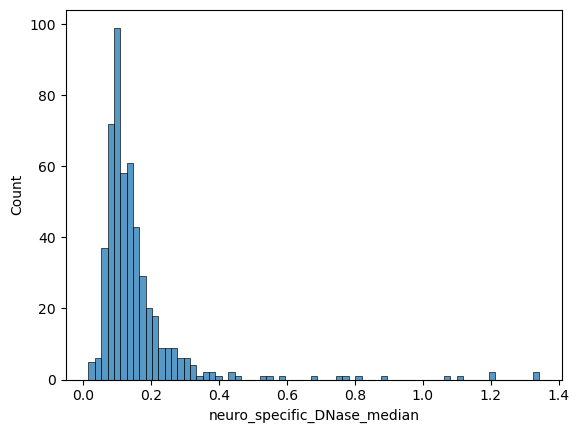

In [ ]:
# significant_enformer_predictions.hist('neuro_specific_DNase_median')

sns.histplot(data=significant_enformer_predictions, x="neuro_specific_DNase_median")
# sns.histplot(data=tested_mpralm_variant_table_enformer_predictions, x="neuro_specific_DNase_median", hue='sig_non_sig')


In [ ]:
# TODO Print non significant

#### Get the numbers of the positive and negative predictive values
- combine enformer class table with the bc MPRAlm results

In [ ]:
import ast # convert string back to list: ast.literal_eval


In [ ]:
all_enformer_variants_table

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,NaN,<NA>,"[('neuro', 'common', 'NA')]",['NA'],['neuro'],['common']
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,NaN,<NA>,"[('neuro', 'common', 'NA')]",['NA'],['neuro'],['common']
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,NaN,<NA>,"[('neuro', 'common', 'NA')]",['NA'],['neuro'],['common']
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,NaN,<NA>,"[('neuro', 'common', 'NA')]",['NA'],['neuro'],['common']
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,NaN,<NA>,"[('neuro', 'common', 'NA')]",['NA'],['neuro'],['common']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69200,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,-0.586787,31_DNASE:iPS-NIHi11 mal,"[('random', 'ultra-rare', 'enformer_low')]",['enformer_low'],['random'],['ultra-rare']
69201,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,-0.961862,90_DNASE:HeLa-S3 G1b ph,"[('random', 'ultra-rare', 'enformer_low')]",['enformer_low'],['random'],['ultra-rare']
69202,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,-0.964058,665_DNASE:testis male ad,"[('random', 'ultra-rare', 'enformer_low')]",['enformer_low'],['random'],['ultra-rare']
69203,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,-1.122092,170_DNASE:iPS DF 4.7 mal,"[('random', 'ultra-rare', 'enformer_low')]",['enformer_low'],['random'],['ultra-rare']


In [ ]:
significant_enformer_predictions = significant_variant_table.merge(sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median']], left_on='REF_ID', right_on='ID', how='left') # 527

In [ ]:
def add_sig_non_sig_label(adj_pvalue):
    if adj_pvalue <0.05:
        return 'sig'
    return 'non_sig'

In [ ]:
# load bc_MPRAlm results
bc_MPRAlm_results = pd.read_csv(config['files']['creating']['toptable_bcMPRAlm_resequencing'], sep="\t")
# for this analysis we focus on tested variants
tested_bc_MPRAlm_results = bc_MPRAlm_results.loc[bc_MPRAlm_results['variant_id'].str.startswith('cardiac_neuro_cava_random')]
print('Number of variants after barcode MPRAlm: ', bc_MPRAlm_results.shape[0])
print('Number of tested variants after barcode MPRAlm: ', tested_bc_MPRAlm_results.shape[0])

tested_mpralm_variant_table = tested_bc_MPRAlm_results.merge(variant_table, left_on='variant_id', right_on='Variant', how='left')
tested_mpralm_variant_table

tested_mpralm_variant_table_enformer_predictions = tested_mpralm_variant_table.merge(sorted_merged_design_enformer[['ID', 'neuro_specific_DNase_median']], left_on='REF_ID', right_on='ID', how='left') # 527
# # load enformer count results (not needed right now)
# enformer_count_table = pd.read_csv(config['files']['creating']['enformer_mprasnakeflow_counts'], sep="\t")
# print('Number of prioritized variants from enformer which could be matched to counts tables of MPRAsnakeflow: ', enformer_count_table.shape[0])

# # load raw enformer variant information
# all_enformer_variants_table = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t", dtype={'DNase_max': float, 'max_col': 'string', 'enformer_class': 'string'})
# columns = ['enformer_variant_info', 'enformer_class_list', 'gene_set_list', 'variant_type_list']
# for col in columns:
#     all_enformer_variants_table[col] = all_enformer_variants_table[col].apply(ast.literal_eval)

# tested_bc_MPRAlm_results['Variant_without_group'] = tested_bc_MPRAlm_results['variant_id'].apply(split_group)
tested_mpralm_variant_table_enformer_predictions['sig_non_sig'] =  tested_mpralm_variant_table_enformer_predictions['adj.P.Val'].apply(add_sig_non_sig_label)	# 36186
tested_mpralm_variant_table_enformer_predictions

Number of variants after barcode MPRAlm:  36694
Number of tested variants after barcode MPRAlm:  36168


,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,Variant,Region,REF_ID,ALT_ID,Variant_without_group,ID,neuro_specific_DNase_median,sig_non_sig
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,0.13340,sig
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,0.17810,sig
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,0.20010,sig
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,0.10520,sig
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,cardiac_neuro_cava_random:REF_CDH1|ENSG0000003...,0.08660,sig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36181,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,cardiac_neuro_cava_random:REF_TMEM70|ENSG00000...,cardiac_neuro_cava_random:ALT_TMEM70|ENSG00000...,TMEM70|ENSG00000175606.11|EH38E3840361|8-74003...,cardiac_neuro_cava_random:REF_TMEM70|ENSG00000...,0.10390,non_sig
36182,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,cardiac_neuro_cava_random:REF_CHD7|ENSG0000017...,cardiac_neuro_cava_random:ALT_CHD7|ENSG0000017...,CHD7|ENSG00000171316.14|EH38E3836279|8-6077768...,cardiac_neuro_cava_random:REF_CHD7|ENSG0000017...,0.06190,non_sig
36183,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,GATA4|ENSG00000136574.19|EH38E2611158|8-118060...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,0.07890,non_sig
36184,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,GATA4|ENSG00000136574.19|E

In [ ]:
non_significant = tested_mpralm_variant_table_enformer_predictions.loc[tested_mpralm_variant_table_enformer_predictions['sig_non_sig'] == 'non_sig']['neuro_specific_DNase_median'].to_list()
sig_enformer = significant_enformer_predictions['neuro_specific_DNase_median'].to_list()

In [ ]:
from scipy.stats import mannwhitneyu
res = mannwhitneyu(sig_enformer, non_significant, alternative='greater', method='asymptotic')


In [ ]:
res

MannwhitneyuResult(statistic=nan, pvalue=nan)

In [ ]:
all_enformer_variants_table['ID'].to_list()

['SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T',
 'SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C',
 'SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T',
 'SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G',
 'SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A',
 'SKI|ENSG00000157933.11|EH38E2778490|1-2191522-C-T',
 'SKI|ENSG00000157933.11|EH38E2778490|1-2191523-G-A',
 'SKI|ENSG00000157933.11|EH38E2778494|1-2193142-G-A',
 'SKI|ENSG00000157933.11|EH38E2778498|1-2194331-T-G',
 'SKI|ENSG00000157933.11|EH38E2778498|1-2194344-T-G',
 'SKI|ENSG00000157933.11|EH38E2778513|1-2203222-G-A',
 'SKI|ENSG00000157933.11|EH38E2778530|1-2209048-G-A',
 'SKI|ENSG00000157933.11|EH38E2778535|1-2210904-C-T',
 'SKI|ENSG00000157933.11|EH38E2778535|1-2211057-C-T',
 'SKI|ENSG00000157933.11|EH38E2778542|1-2213776-A-G',
 'SKI|ENSG00000157933.11|EH38E2778542|1-2213782-G-A',
 'SKI|ENSG00000157933.11|EH38E2778542|1-2213790-G-C',
 'SKI|ENSG00000157933.11|EH38E2778542|1-2213798-G-A',
 'SKI|ENSG00000157933.11|EH3

In [ ]:
tested_bc_MPRAlm_results['Variant_without_group'].to_list()

['TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'RAD51B|ENSG00000182185.19|EH38E3101219|14-68160488-A-G',
 'SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'H1-3|ENSG00000124575.7|EH38E3697642|6-26200568-C-A',
 'DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G',
 'R3HDML|ENSG00000101074.5|EH38E2114680|20-44320090-C-T',
 'LMNA|ENSG00000160789.24|EH38E1387716|1-156152803-G-A',
 'CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115723-G-T',
 'H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'ARHGAP31|ENSG00000031081.11|EH38E3533509|3-119305469-T-C',
 'NCOA1|ENSG00000084676.16|EH38E3330961|2-24521257-G-A',
 'NRXN1|ENSG00000179915

In [ ]:
bcMPRAlm_enformer_variants = tested_bc_MPRAlm_results.merge(all_enformer_variants_table, left_on='Variant_without_group', right_on='ID')
merged_bcMPRAlm_enformer_variants = bcMPRAlm_enformer_variants.loc[bcMPRAlm_enformer_variants['enformer_variant_info'].isna()]
print('mergable variants: ', merged_bcMPRAlm_enformer_variants.shape[0])

mergable variants:  0
